In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [60]:
df = pd.read_csv("/home/margaritisvoliotis/Documents/AMR classification model/AMR_classification_model-Tailise1-patch-1/CIP_23_best_features.csv")

df

,exp_order,exp_id,file,sample_id,species,strain_name,strain_phenotype,MIC Sensititre,dataset,over_drug-060-090_drug-030-060__over_p30_04000-05000Hz_p30_00000-00010Hz,...,std_var_length_drug 3h,mean_var_length_drug 2.5h,max_var_length_drug 3h,max_var_length_drug 2.5h,std_var_length_drug 2.5h,mean_var_length_drug 1.5h,std_var_length_drug 1.5h,resistant_cells_percentage_drug_2.5h,resistant_cells_percentage_drug_2h,Length var coef drug
0,448,42ff15,qsd-features-20220607/240808_42ff15-22602.bin,nfCIP031,P. aeruginosa,CH5528,R,NaN,permanent_test,0.27,...,0.399362,0.811110,1.705302,0.879961,0.119705,0.756175,0.175060,53.333333,78.333333,0.157017
1,449,47011b,qsd-features-20220607/240808_47011b-22631.bin,nfCIP031,P. aeruginosa,CH5528,R,NaN,permanent_test,0.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,450,120529,qsd-features-20220607/240808_120529-22611.bin,nfCIP031,P. aeruginosa,CH5528,R,NaN,permanent_test,0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,451,150563,qsd-features-20220607/240829_150563-23003.bin,nfCIP049,P. aeruginosa,MHH14929,R,NaN,permanent_test,0.59,...,0.097138,0.368637,0.480262,0.480262,0.101674,0.448991,0.044223,0.000000,3.333333,0.185707
4,452,22044c,qsd-features-20220607/240829_22044c-23002.bin,nfCIP049,P. aeruginosa,MHH14929,R,NaN,permanent_test,0.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,512,33014b,qsd-features-20220607/250904_33014b-26852.bin,MAD119,P. aeruginosa,ESP009,R,NaN,permanent_test,1.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,513,340128,qsd-features-20220607/250904_340128-26851.bin,MAD119,P. aeruginosa,ESP009,R,NaN,permanent_test,0.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,514,320150,qsd-features-20220607/250905_320150-26858.bin,MAD120,P. aeruginosa,ESP012,R,NaN,permanent_test,0.79,...,0.033929,0.556642,0.596118,0.596118,0.043468,0.558609,0.053047,80.000000,95.000000,0.057970
67,515,33014c,qsd-features-20220607/250905_33014c-26859.bin,MAD120,P. aeruginosa,ESP012,R,NaN,permanent_test,0.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
nanomotion_features = df.iloc[:, 9:19]


In [62]:
nanomotion_features

,over_drug-060-090_drug-030-060__over_p30_04000-05000Hz_p30_00000-00010Hz,over_drug-030-060_drug-000-030__over_over_minus_p90_p10_minus_p60_p40_00400-01000Hz_over_minus_p90_p10_minus_p60_p40_00100-00200Hz,over_drug-030-060_drug-000-030__over_p50_07000-08000Hz_p50_06000-07000Hz,over_drug-060-090_drug-000-030__over_p50_08000-10000Hz_p50_04000-05000Hz,drug-000-030__over_minus_p90_p10_06000-07000Hz_minus_p90_p10_01000-02000Hz,over_drug-060-090_drug-000-030__p70_08000-10000Hz,over_drug-060-090_drug-030-060__over_minus_p90_p50_08000-10000Hz_minus_p90_p50_07000-08000Hz,over_drug-060-090_drug-030-060__over_minus_p60_p40_08000-10000Hz_minus_p60_p40_04000-05000Hz,over_drug-060-090_drug-030-060__over_p90_02000-04000Hz_p90_00100-00200Hz,drug-030-060__over_p20_07000-08000Hz_p20_01000-02000Hz
0,0.27,1.03,1.00,1.01,6.29,1.01,1.00,1.00,0.52,10.02
1,0.80,0.97,1.00,1.00,6.28,1.06,1.00,0.99,0.82,9.84
2,0.50,0.98,1.00,1.01,6.45,1.01,1.00,1.00,1.20,9.89
3,0.59,0.94,1.00,0.98,6.09,1.00,0.99,0.99,0.63,9.45
4,0.54,0.98,1.00,0.98,6.13,1.04,0.98,0.98,0.50,9.31
...,...,...,...,...,...,...,...,...,...,...
64,1.26,1.01,1.01,1.02,5.67,1.02,1.00,1.01,1.10,8.98
65,0.52,0.96,1.00,1.00,6.05,1.00,1.00,0.99,0.59,9.57
66,0.79,1.09,1.00,1.02,5.52,1.01,1.00,1.01,0.92,8.73
67,0.59,0.88,1.00,1.00,5.65,1.01,1.00,1.00,0.79,8.76


In [63]:
microfluidics_features = df.iloc[:,40:50]
microfluidics_features = microfluidics_features.dropna()
# Applying the method
check_nan = microfluidics_features.isnull().values.any()
# printing the result
print(check_nan)

False


In [64]:
microfluidics_features

,mean_var_length_drug 3h,std_var_length_drug 3h,mean_var_length_drug 2.5h,max_var_length_drug 3h,max_var_length_drug 2.5h,std_var_length_drug 2.5h,mean_var_length_drug 1.5h,std_var_length_drug 1.5h,resistant_cells_percentage_drug_2.5h,resistant_cells_percentage_drug_2h
0,1.051808,0.399362,0.811110,1.705302,0.879961,0.119705,0.756175,0.175060,53.333333,78.333333
3,0.332749,0.097138,0.368637,0.480262,0.480262,0.101674,0.448991,0.044223,0.000000,3.333333
6,3.056454,1.018101,2.877507,3.907634,0.572292,0.072001,0.477855,0.047367,28.333333,60.000000
9,0.743663,0.198668,0.661816,1.064225,0.878552,0.150269,0.572226,0.057488,35.000000,70.000000
12,0.333961,0.092097,0.299639,0.498608,0.375127,0.057271,0.327682,0.067098,55.000000,90.000000
15,1.798038,1.265963,2.415369,3.797151,3.797151,0.967015,3.083933,1.008642,0.000000,0.000000
18,6.258197,4.842615,3.316668,13.432974,5.909392,1.833612,2.070599,0.498691,0.000000,3.333333
21,2.440751,1.584758,1.597574,4.343991,3.161191,1.144822,0.765345,0.302610,0.000000,3.333333
24,4.438974,3.243955,2.582580,9.824426,4.160825,1.374315,1.462562,0.478033,0.000000,1.666667
27,4.322394,2.758819,2.819658,7.831848,5.403376,1.866266,1.508021,0.575244,3.333333,5.000000


In [65]:
# Take mean of each group of 3 rows
nanomotion_triplet_mean = (
    nanomotion_features
    .groupby(np.arange(len(nanomotion_features)) // 3)
    .mean()
)
nanomotion_triplet_mean

,over_drug-060-090_drug-030-060__over_p30_04000-05000Hz_p30_00000-00010Hz,over_drug-030-060_drug-000-030__over_over_minus_p90_p10_minus_p60_p40_00400-01000Hz_over_minus_p90_p10_minus_p60_p40_00100-00200Hz,over_drug-030-060_drug-000-030__over_p50_07000-08000Hz_p50_06000-07000Hz,over_drug-060-090_drug-000-030__over_p50_08000-10000Hz_p50_04000-05000Hz,drug-000-030__over_minus_p90_p10_06000-07000Hz_minus_p90_p10_01000-02000Hz,over_drug-060-090_drug-000-030__p70_08000-10000Hz,over_drug-060-090_drug-030-060__over_minus_p90_p50_08000-10000Hz_minus_p90_p50_07000-08000Hz,over_drug-060-090_drug-030-060__over_minus_p60_p40_08000-10000Hz_minus_p60_p40_04000-05000Hz,over_drug-060-090_drug-030-060__over_p90_02000-04000Hz_p90_00100-00200Hz,drug-030-060__over_p20_07000-08000Hz_p20_01000-02000Hz
0,0.523333,0.993333,1.000000,1.006667,6.340000,1.026667,1.000000,0.996667,0.846667,9.916667
1,0.583333,0.966667,1.000000,0.990000,6.236667,1.016667,0.990000,0.990000,0.630000,9.736667
2,0.850000,0.983333,1.000000,1.003333,5.483333,1.006667,1.000000,1.000000,0.756667,8.623333
3,0.660000,0.986667,1.000000,1.006667,6.620000,1.006667,1.000000,1.000000,0.810000,10.170000
4,0.983333,0.986667,1.000000,1.020000,6.040000,1.026667,1.000000,1.006667,1.050000,9.453333
5,1.266667,0.953333,1.000000,1.013333,5.990000,1.003333,0.996667,1.003333,1.070000,9.436667
6,1.500000,0.976667,1.000000,1.000000,6.013333,1.006667,0.996667,0.996667,1.196667,9.566667
7,1.040000,0.996667,1.000000,1.016667,5.656667,0.996667,1.000000,1.003333,1.210000,8.930000
8,1.533333,0.990000,1.020000,1.086667,6.026667,1.026667,1.006667,1.013333,1.150000,9.336667
9,1.826667,1.006667,1.000000,0.996667,5.140000,1.003333,0.996667,1.000000,1.413333,7.963333


## Correlation computation

The correlation used in this analysis is the **Pearson correlation coefficient**, which measures the linear relationship between two variables. It is the default method used by:

```python
nanomotion_triplet_mean[nano_col].corr(amr_features[amr_col])


In [66]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [67]:
def plot_display_save_heatmap(corr_matrix, title, filename):
    plt.figure(figsize=(18, 14))
    plt.imshow(corr_matrix, aspect='auto')
    plt.colorbar()

    # Big column labels
    plt.xticks(
        range(len(corr_matrix.columns)),
        corr_matrix.columns,
        rotation=90,
        fontsize=16,
        fontweight='bold'
    )

    plt.yticks(
        range(len(corr_matrix.index)),
        corr_matrix.index,
        fontsize=16
    )

    plt.title(title, fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.40, left=0.25)

    # --- SAVE BEFORE SHOW ---
    plt.savefig(os.path.join(output_folder, filename),
                dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()


In [68]:
# --- Make sure the folder exists ---
output_folder = "correlation_results"
os.makedirs(output_folder, exist_ok=True)

# --- Function to compute full pairwise correlation matrix ---
def compute_corr_matrix_loop(df1, df2, method='pearson'):
    corr_matrix = pd.DataFrame(
        np.zeros((df1.shape[1], df2.shape[1])),
        index=df1.columns,
        columns=df2.columns
    )
    for nano_col in df1.columns:
        for micro_col in df2.columns:
            corr_matrix.loc[nano_col, micro_col] = df1[nano_col].corr(df2[micro_col], method=method)
    return corr_matrix

# # --- Compute correlation matrices ---
# corr_matrix_pearson = compute_corr_matrix_loop(nanomotion_triplet_mean, microfluidics_features, method='pearson')
# corr_matrix_spearman = compute_corr_matrix_loop(nanomotion_triplet_mean, microfluidics_features, method='spearman')
# corr_matrix_kendall = compute_corr_matrix_loop(nanomotion_triplet_mean, microfluidics_features, method='kendall')




# # --- Plot, display, and save all three heatmaps ---
# plot_display_save_heatmap(corr_matrix_pearson, 
#                           "Pearson Correlation Heatmap: Nanomotion vs Microfluidics Features", 
#                           "pearson_correlation_heatmap.png")

# plot_display_save_heatmap(corr_matrix_spearman, 
#                           "Spearman Correlation Heatmap: Nanomotion vs Microfluidics Features", 
#                           "spearman_correlation_heatmap.png")

# plot_display_save_heatmap(corr_matrix_kendall, 
#                           "Kendall Tau Correlation Heatmap: Nanomotion vs Microfluidics Features", 
#                           "kendall_correlation_heatmap.png")


In [69]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau

def compute_corr_and_p(df1, df2, method='pearson'):
    corr_matrix = pd.DataFrame(
        index=df1.columns,
        columns=df2.columns,
        dtype=float
    )
    p_matrix = corr_matrix.copy()

    for c1 in df1.columns:
        for c2 in df2.columns:

            # Align the series on common index
            x, y = df1[c1].align(df2[c2], join='inner')
            mask = x.notna() & y.notna()
            x = x[mask].values
            y = y[mask].values

            if len(x) < 2:
                r, p = np.nan, np.nan
            else:
                if method == 'pearson':
                    r, p = pearsonr(x, y)
                elif method == 'spearman':
                    r, p = spearmanr(x, y)
                elif method == 'kendall':
                    r, p = kendalltau(x, y)  # Kendall τ
                else:
                    raise ValueError("method must be 'pearson', 'spearman', or 'kendall'")

            corr_matrix.loc[c1, c2] = r
            p_matrix.loc[c1, c2] = p

    return corr_matrix, p_matrix


In [70]:
# import pandas as pd
# import numpy as np
# from scipy.stats import pearsonr, spearmanr, kendalltau
# from statsmodels.stats.multitest import multipletests

# def compute_corr_and_p(df1, df2, method='pearson', fdr_method='fdr_bh'):
#     corr_matrix = pd.DataFrame(
#         index=df1.columns,
#         columns=df2.columns,
#         dtype=float
#     )
#     p_matrix = corr_matrix.copy()

#     for c1 in df1.columns:
#         for c2 in df2.columns:

#             # Align the series on common index
#             x, y = df1[c1].align(df2[c2], join='inner')
#             mask = x.notna() & y.notna()
#             x = x[mask].values
#             y = y[mask].values

#             if len(x) < 2:
#                 r, p = np.nan, np.nan
#             else:
#                 if method == 'pearson':
#                     r, p = pearsonr(x, y)
#                 elif method == 'spearman':
#                     r, p = spearmanr(x, y)
#                 elif method == 'kendall':
#                     r, p = kendalltau(x, y)
#                 else:
#                     raise ValueError("method must be 'pearson', 'spearman', or 'kendall'")

#             corr_matrix.loc[c1, c2] = r
#             p_matrix.loc[c1, c2] = p

#     # ---------- FDR correction ----------
#     pvals = p_matrix.values.flatten()
#     valid = ~np.isnan(pvals)

#     pvals_fdr = np.full_like(pvals, np.nan, dtype=float)

#     if valid.any():
#         _, pvals_fdr[valid], _, _ = multipletests(
#             pvals[valid],
#             method=fdr_method
#         )

#     p_fdr_matrix = pd.DataFrame(
#         pvals_fdr.reshape(p_matrix.shape),
#         index=p_matrix.index,
#         columns=p_matrix.columns
#     )

#     return corr_matrix, p_matrix, p_fdr_matrix


In [71]:
def p_to_stars(p):
    if pd.isna(p):
        return ""
    elif p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 5e-2:
        return "*"
    else:
        return ""


In [72]:
# def plot_corr_with_sig_imshow(
#     corr,
#     pvals,
#     title,
#     filename,
#     output_folder,
#     alpha=0.05
# ):
#     plt.figure(figsize=(18, 14))

#     # Plot correlation matrix
#     im = plt.imshow(
#         corr,
#         aspect='auto',
#         #cmap='coolwarm',
#         vmin=-1,
#         vmax=1
#     )

#     plt.colorbar(im)

#     # Axis labels
#     plt.xticks(
#         range(len(corr.columns)),
#         corr.columns,
#         rotation=90,
#         fontsize=16,
#         fontweight='bold'
#     )

#     plt.yticks(
#         range(len(corr.index)),
#         corr.index,
#         fontsize=16
#     )

#     # Add stars for significant p-values
#     for i in range(corr.shape[0]):
#         for j in range(corr.shape[1]):
#             if pvals.iloc[i, j] < alpha:
#                 plt.text(
#                     j, i, '*',
#                     ha='center',
#                     va='center',
#                     color='black',
#                     fontsize=18,
#                     fontweight='bold'
#                 )

#     plt.title(title, fontsize=14)

#     plt.tight_layout()
#     plt.subplots_adjust(bottom=0.40, left=0.25)

#     # Save before show
#     plt.savefig(
#         os.path.join(output_folder, filename),
#         dpi=300,
#         bbox_inches='tight'
#     )

#     plt.show()
#     plt.close()


In [73]:

def plot_corr_with_sig_imshow(
    corr,
    pvals,
    title,
    filename,
    output_folder,
    alpha=0.05
):
    plt.figure(figsize=(18, 14))

    # Plot correlation matrix
    im = plt.imshow(
        corr,
        aspect='auto',
        #cmap='coolwarm',
        vmin=-1,
        vmax=1
    )

    plt.colorbar(im)

    # Axis labels
    plt.xticks(
        range(len(corr.columns)),
        corr.columns,
        rotation=90,
        fontsize=16,
        fontweight='bold'
    )

    plt.yticks(
        range(len(corr.index)),
        corr.index,
        fontsize=16
    )

    # Add stars for significant p-values
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if pvals.iloc[i, j] < alpha:
                plt.text(
                    j, i, '*',
                    ha='center',
                    va='center',
                    color='black',
                    fontsize=18,
                    fontweight='bold'
                )

    plt.title(title, fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.40, left=0.25)

    # Save before show
    plt.savefig(
        os.path.join(output_folder, filename),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

# Correlation with Nanomotion features

In [74]:
corr_pear, pvals_pear = compute_corr_and_p(nanomotion_triplet_mean, microfluidics_features, method='pearson')
corr_spear, pvals_spear = compute_corr_and_p(nanomotion_triplet_mean, microfluidics_features, method='spearman')
corr_kendall, pvals_kendall = compute_corr_and_p(nanomotion_triplet_mean, microfluidics_features, method='kendall')

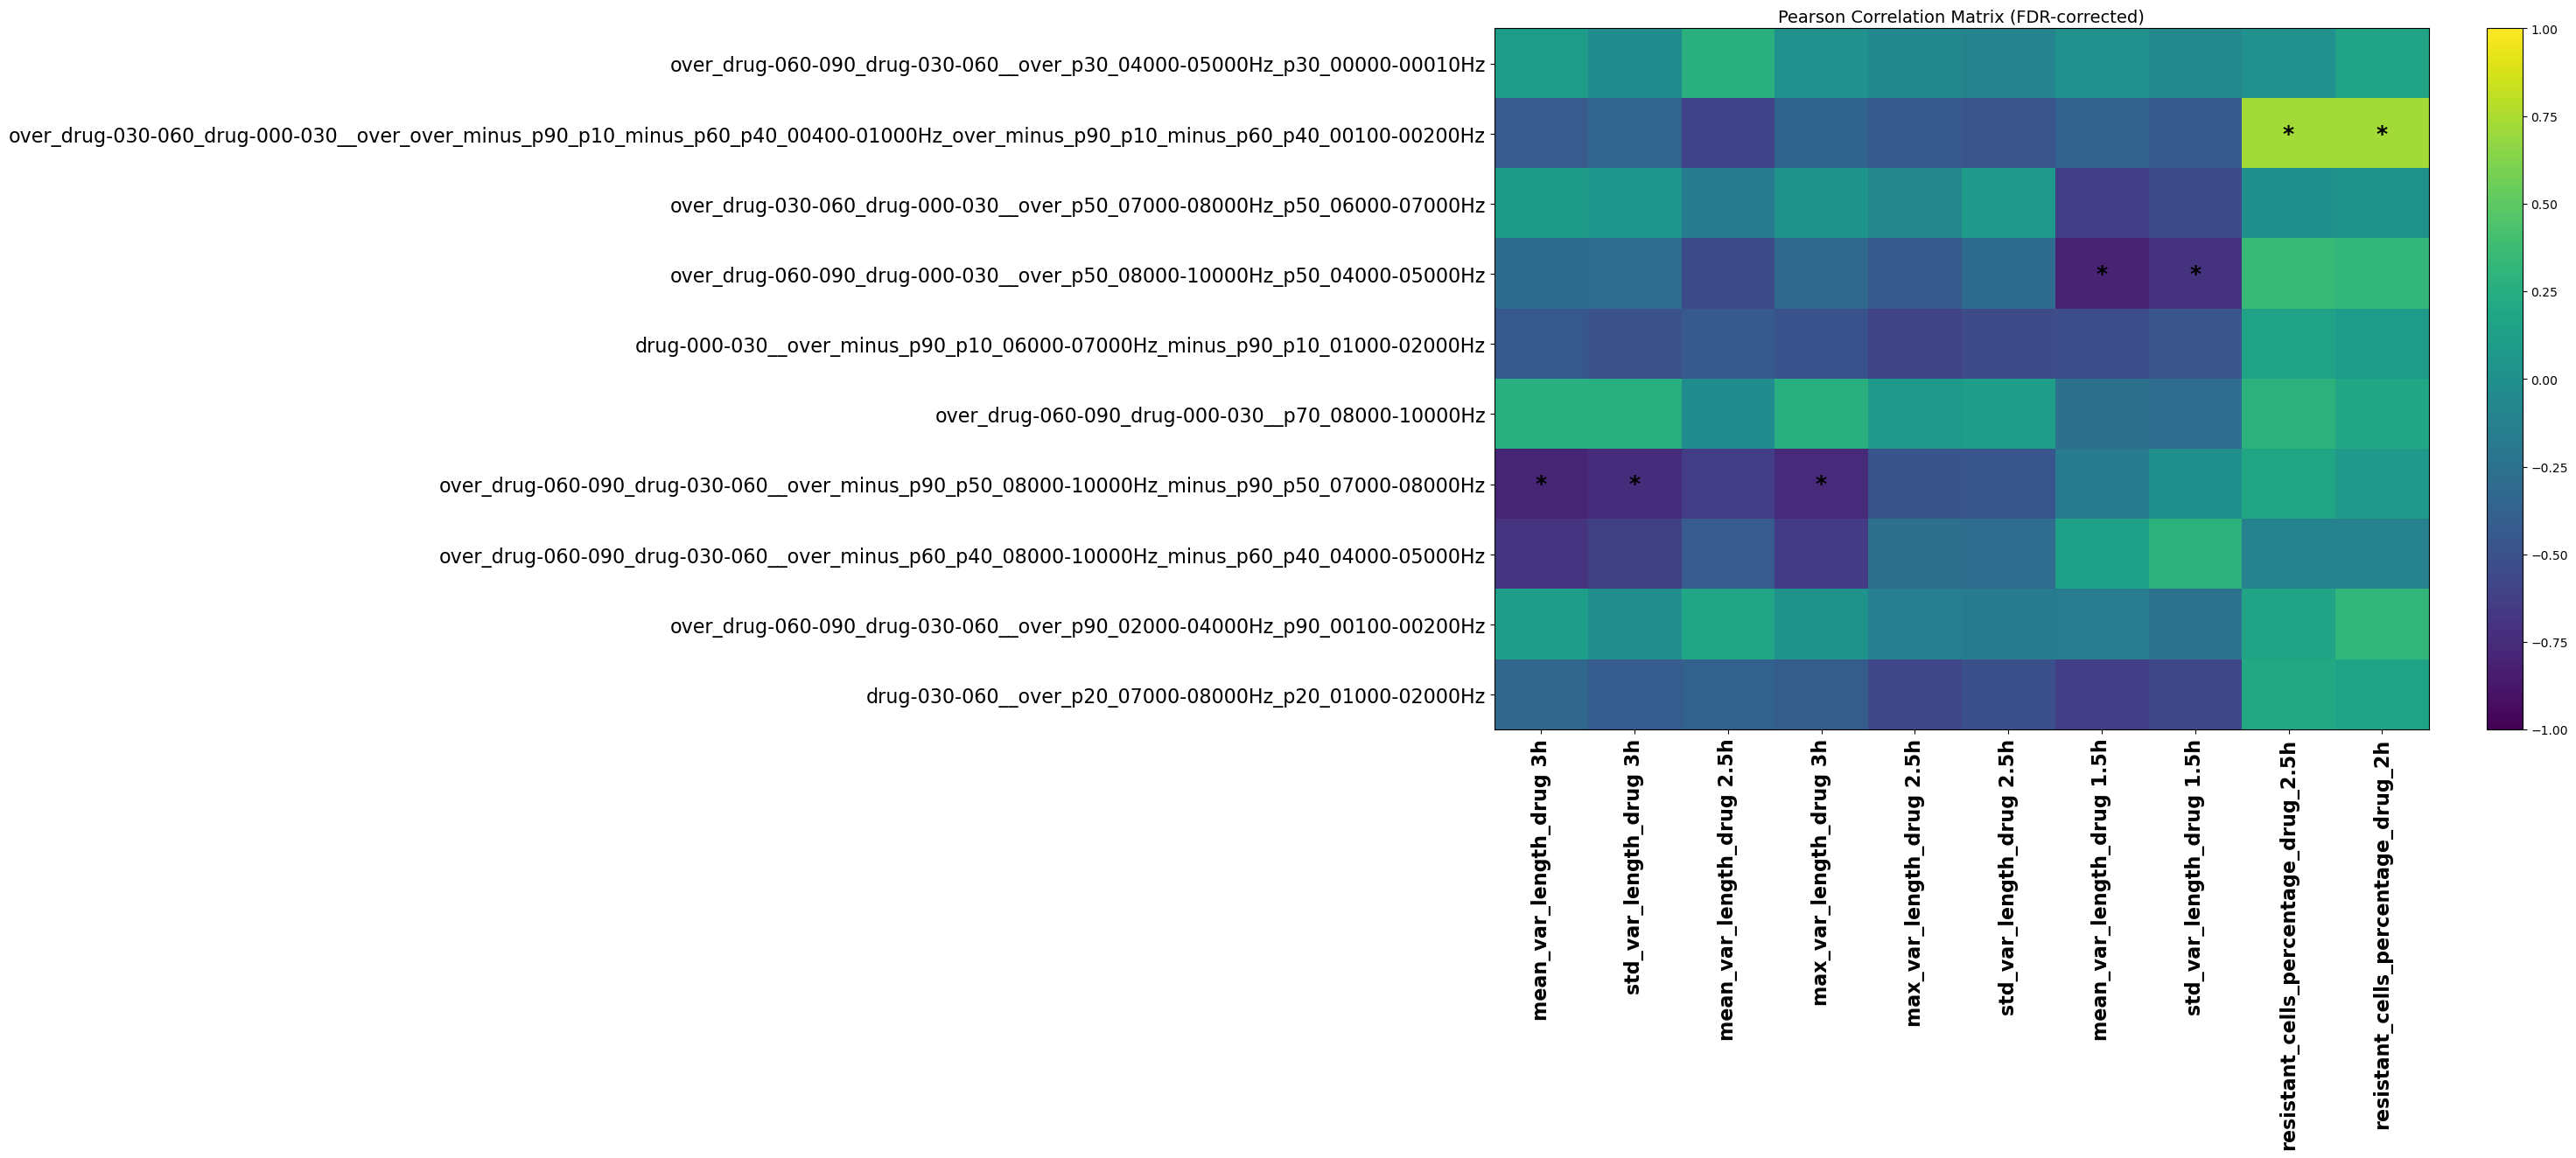

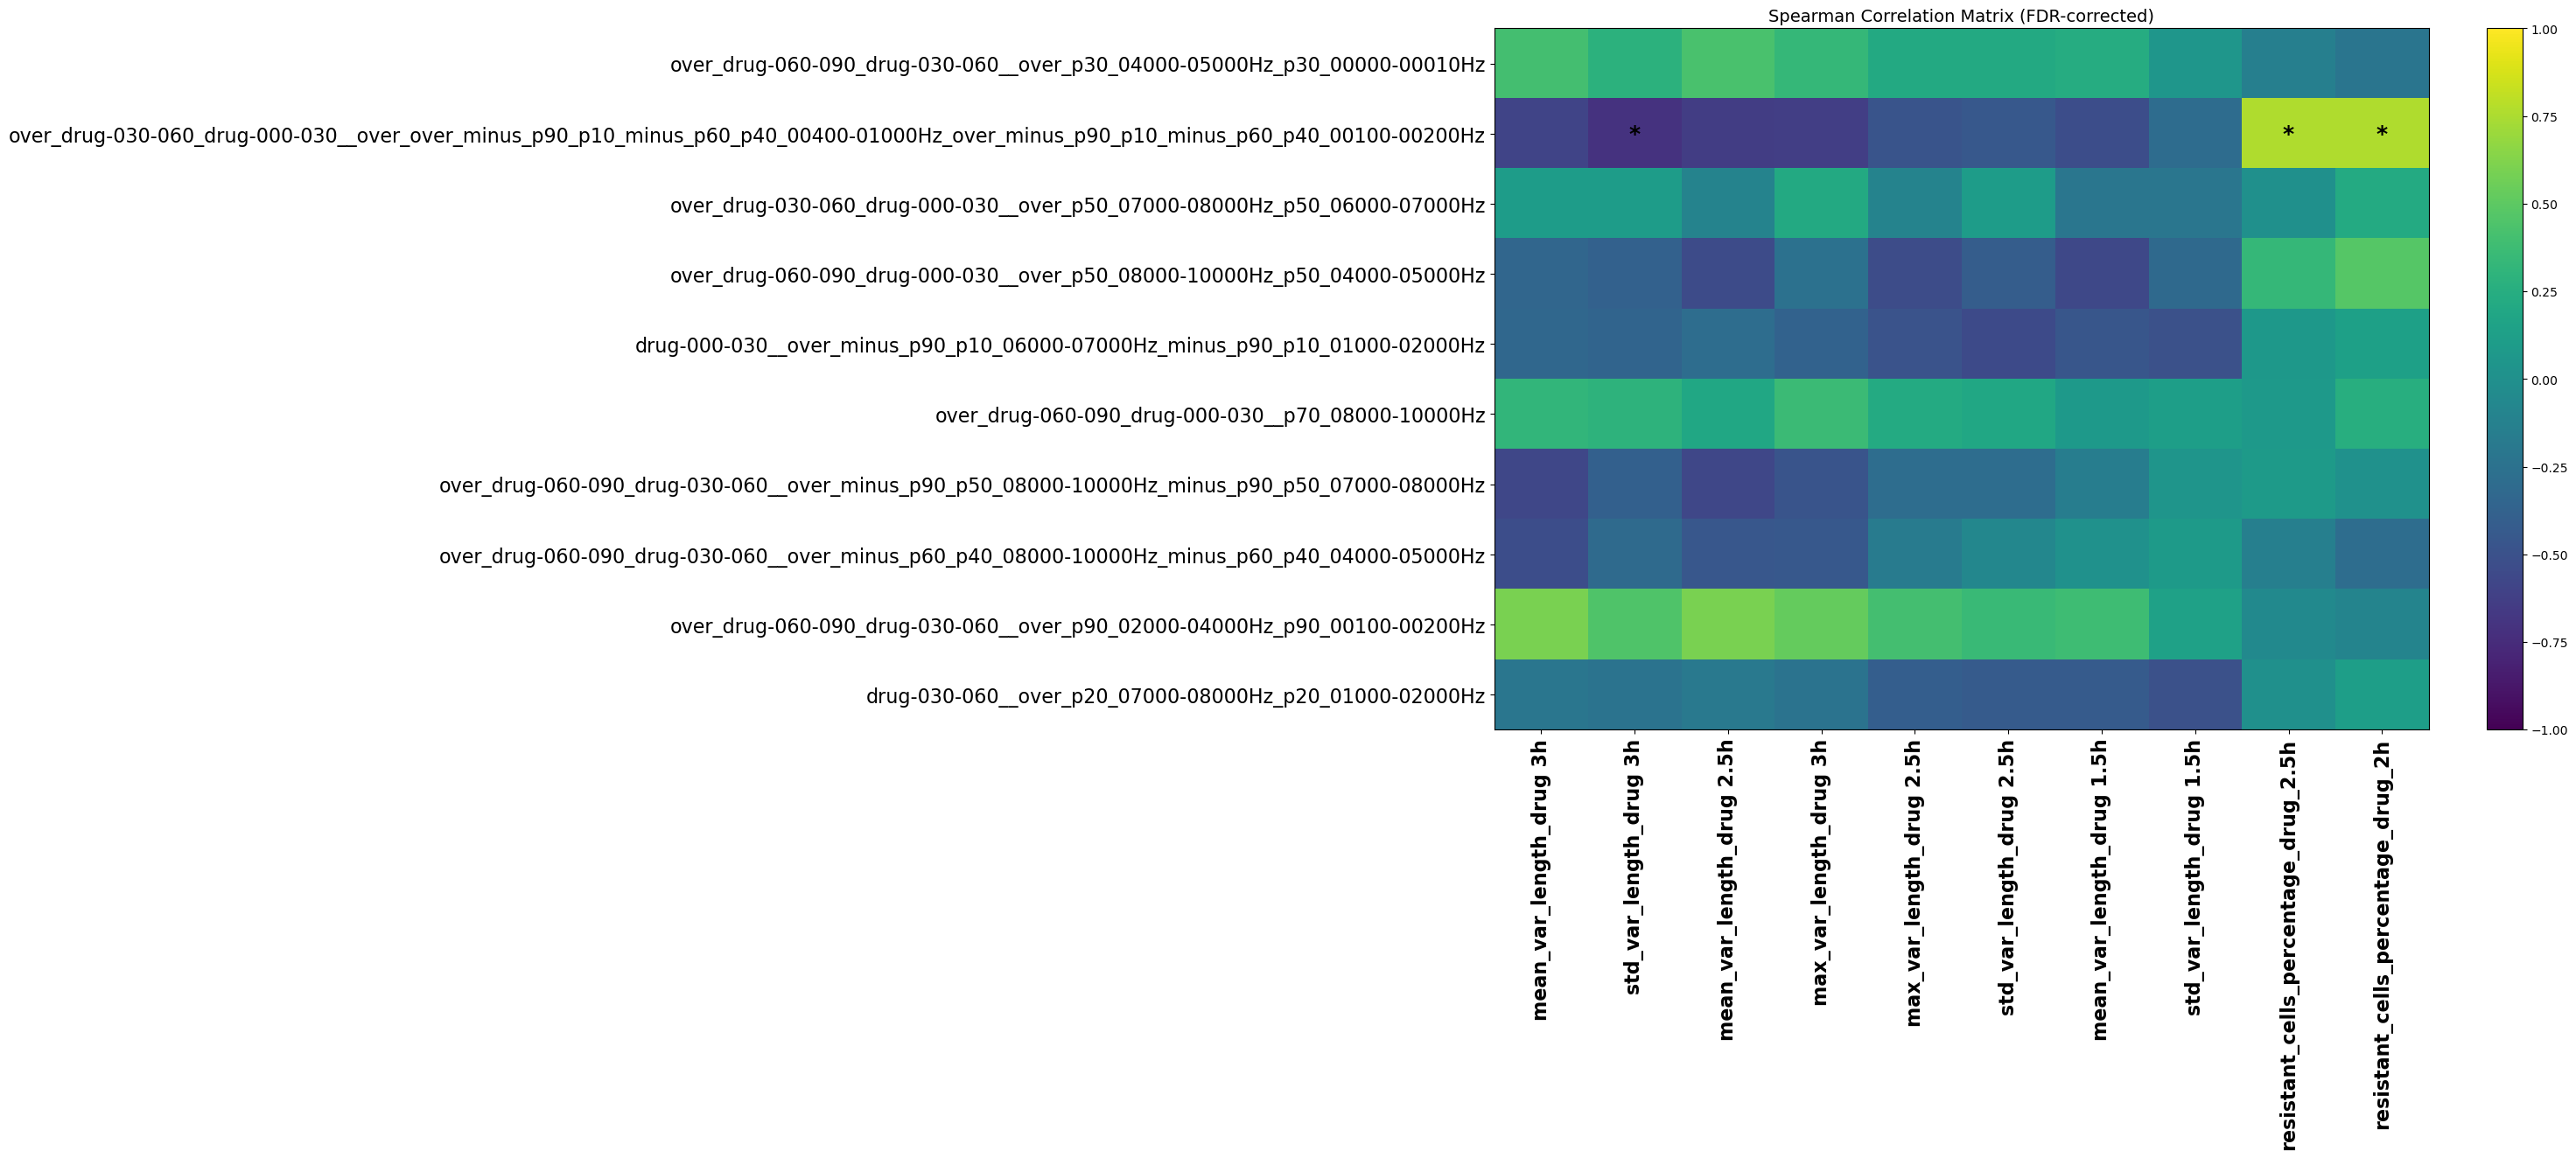

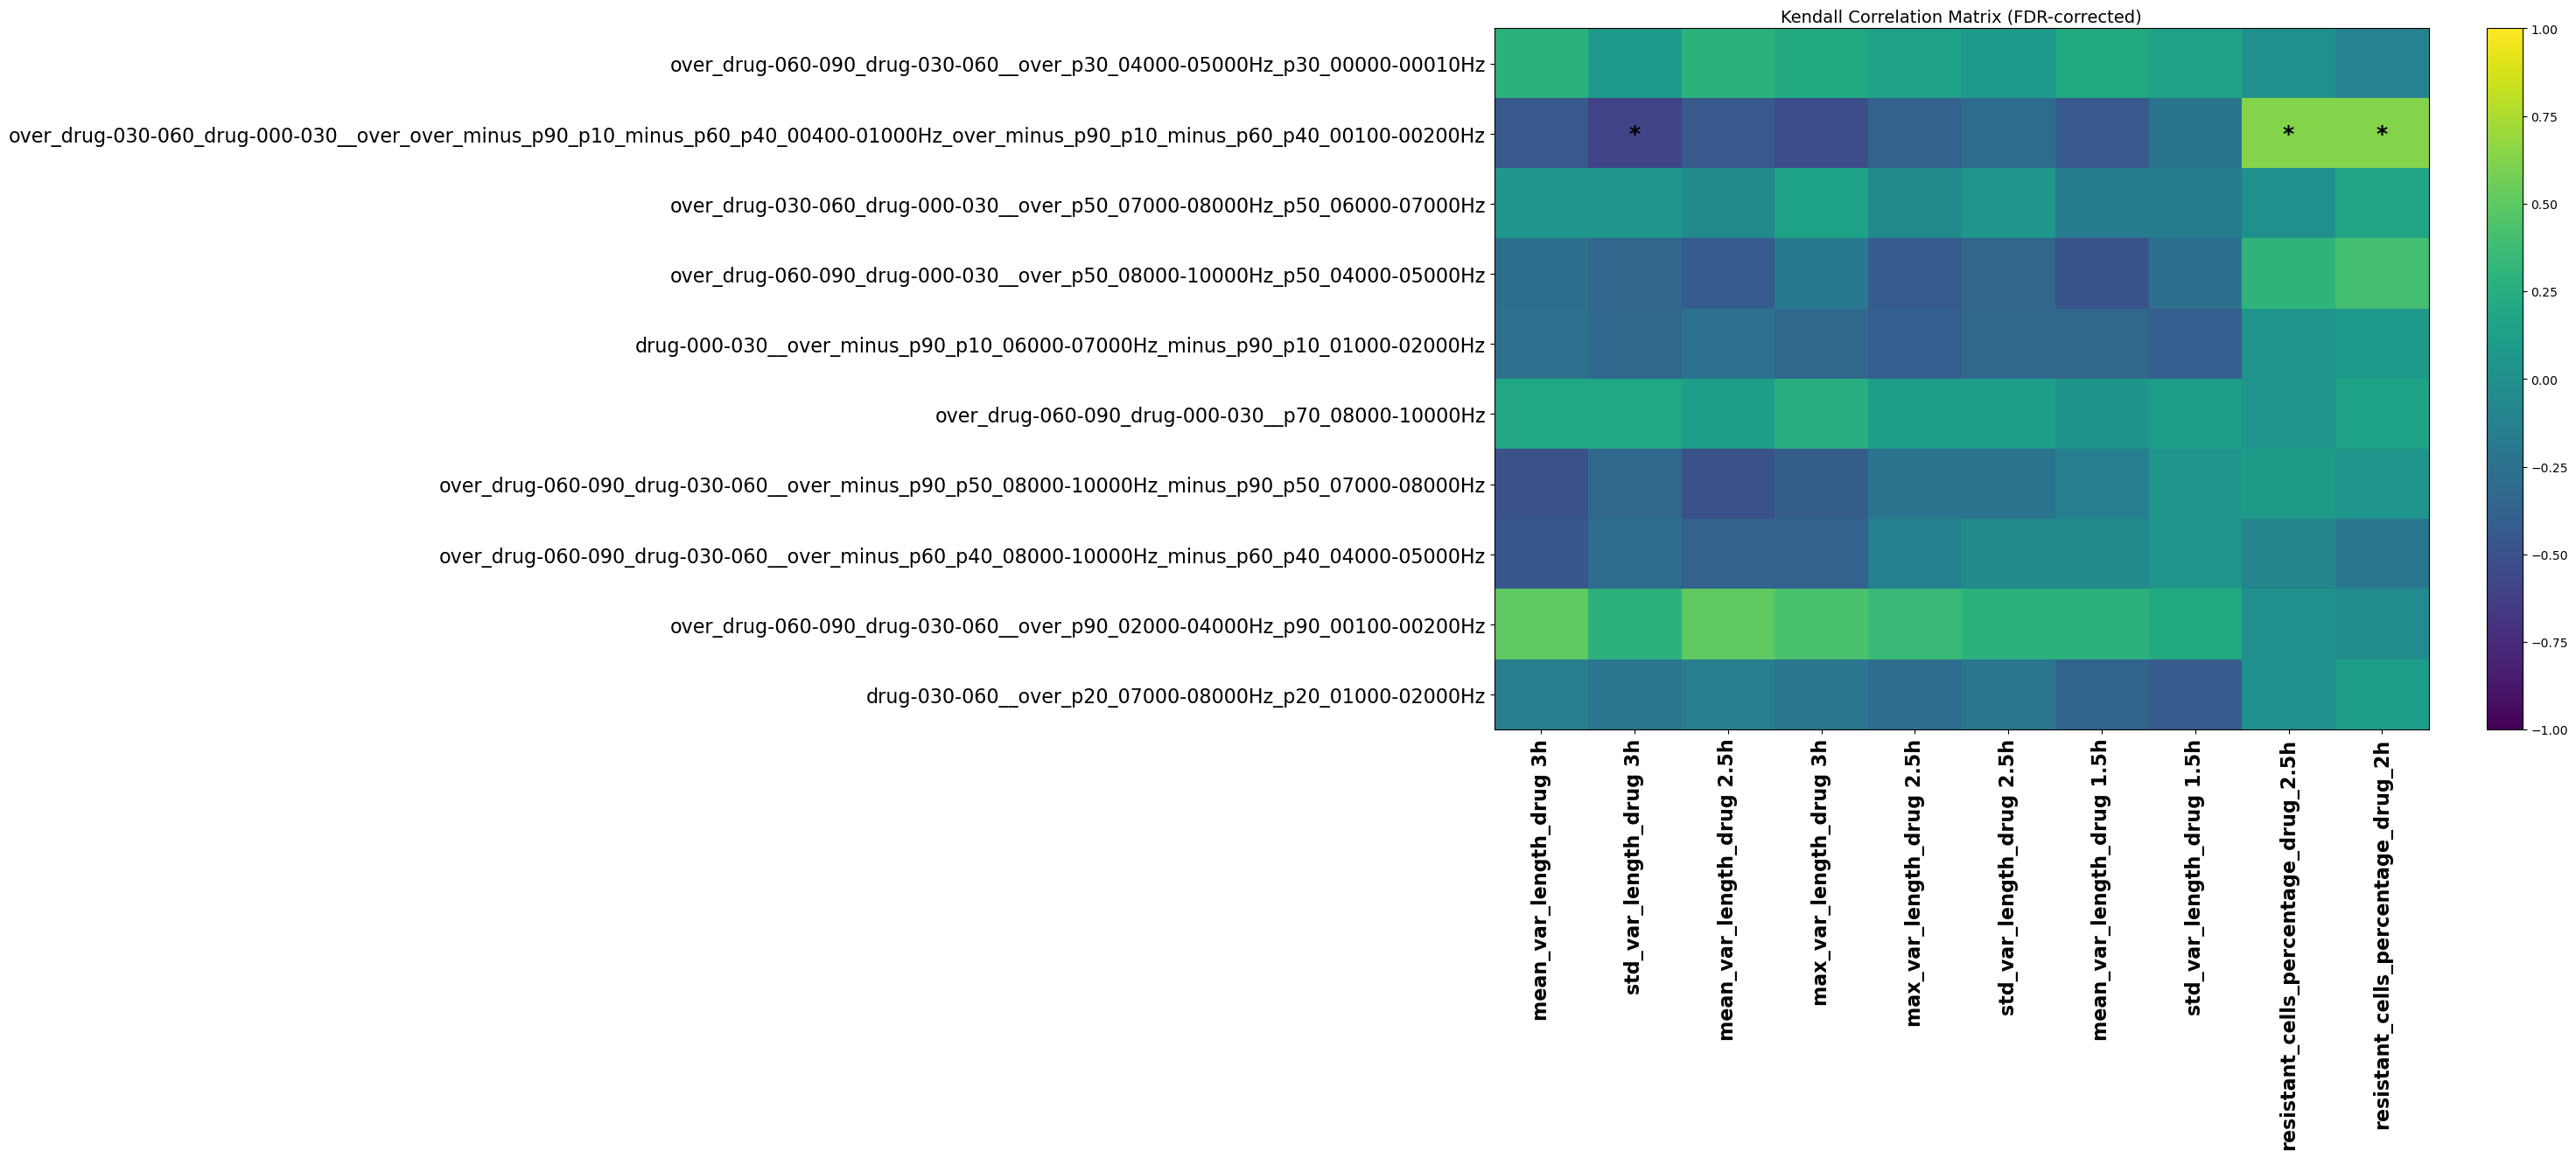

In [75]:
# corr_pear, pvals_pear, p_fdr_pear = compute_corr_and_p(nanomotion_triplet_mean, microfluidics_features, method='pearson')
# corr_spear, pvals_spear, p_fdr_spear = compute_corr_and_p(nanomotion_triplet_mean, microfluidics_features, method='spearman')
# corr_kendall, pvals_kendall, p_fdr_kendall = compute_corr_and_p(nanomotion_triplet_mean, microfluidics_features, method='kendall')

plot_corr_with_sig_imshow(
    corr=corr_pear,
    pvals=pvals_pear,   # 👈 use FDR if available
    title="Pearson Correlation Matrix (FDR-corrected)",
    filename="nanomotion_pear_corr_with_sig.png",
    output_folder=output_folder,
    alpha = 0.05
)

plot_corr_with_sig_imshow(
    corr=corr_spear,
    pvals=pvals_spear,
    title="Spearman Correlation Matrix (FDR-corrected)",
    filename="nanomotion_spear_corr_with_sig.png",
    output_folder=output_folder,
    alpha = 0.05
)

plot_corr_with_sig_imshow(
    corr=corr_kendall,
    pvals=pvals_kendall,
    title="Kendall Correlation Matrix (FDR-corrected)",
    filename="nanomotion_kendall_corr_with_sig.png",
    output_folder=output_folder,
    alpha = 0.05
)

    

Pearson p-values are computed by transforming the correlation coefficient into a t-statistic and testing it against a t-distribution under the assumption of zero true correlation.

In [76]:
# plot each pair

In [77]:
# # calculate correlation significance
# from scipy.stats import pearsonr, spearmanr

# r, p = pearsonr(nanomotion_triplet_mean, microfluidics_features)
# print("Correlation:", r)
# print("p-value:", p)

# # If p is an array of p-values, iterate through it
# for value in p:
#     if value < 0.05:
#         print("significant")
#     else:
#         print("not significant")


In [78]:
# rho, p = spearmanr(nanomotion_triplet_mean, microfluidics_features)
# print("Spearman correlation:", rho)
# print("p-value:", p)

In [79]:
# prediction score vs MIC (from nanomotion)

In [80]:
# correlation between colony size... with features (frm drug free exoeriment) p-hacking

# Correlation with phenotypic features

In [81]:
df_phenotypic = pd.read_csv("/home/margaritisvoliotis/Documents/AMR classification model/251119_414_updated_phenotypic_data_from_Susanne_with_nanomotion_data_for_Marina.csv")


In [82]:
df_phenotypic


,strain,pangenome_name,c_di_GMP,OCR_value,Origin,Geographic_Origin,Supplier_Strain_collection,Infection_site_sample_material,Type_of_infection,TOB,...,over_drug-060-090_drug-030-060__over_p30_04000-05000Hz_p30_00000-00010Hz,over_drug-030-060_drug-000-030__over_over_minus_p90_p10_minus_p60_p40_00400-01000Hz_over_minus_p90_p10_minus_p60_p40_00100-00200Hz,over_drug-030-060_drug-000-030__over_p50_07000-08000Hz_p50_06000-07000Hz,over_drug-060-090_drug-000-030__over_p50_08000-10000Hz_p50_04000-05000Hz,drug-000-030__over_minus_p90_p10_06000-07000Hz_minus_p90_p10_01000-02000Hz,over_drug-060-090_drug-000-030__p70_08000-10000Hz,over_drug-060-090_drug-030-060__over_minus_p90_p50_08000-10000Hz_minus_p90_p50_07000-08000Hz,over_drug-060-090_drug-030-060__over_minus_p60_p40_08000-10000Hz_minus_p60_p40_04000-05000Hz,over_drug-060-090_drug-030-060__over_p90_02000-04000Hz_p90_00100-00200Hz,drug-030-060__over_p20_07000-08000Hz_p20_01000-02000Hz
0,CF592Iso2,CF592Iso2,NaN,NaN,University hospital Essen,Essen,University hospital Essen,Cystic fibrosis,respiratory tract,2.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
1,CF609Iso3,CF609Iso3,NaN,NaN,University hospital Essen,Essen,University hospital Essen,Cystic fibrosis,respiratory tract,8.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
2,CH2500,CH2500,NaN,NaN,Charité Berlin,Berlin,Charité Berlin,tracheobronchial secretion,respiratory tract,0.5,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
3,CH2502,CH2502,NaN,392.459468,Charité Berlin,Berlin,Charité Berlin,nd/other,nd/other,4.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
4,CH2522,CH2522,NaN,377.147813,Charité Berlin,Berlin,Charité Berlin,rectal smear,rectal infection,2.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,ZG5089456,ZG5089456,NaN,NaN,Leipzig,nd,nd,sputum CF,respiratory tract,128.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
412,ZG8006959,ZG8006959,NaN,NaN,Leipzig,Leipzig,Leipzig,urinary tract (Chronic),urinary tract,128.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A
413,ZG8038581181,ZG8038581181,2.232354,274.264000,Chemnitz,Chemnitz,Chemnitz,tracheobronchial secretion,respiratory tract,1.0,...,0.244023479133575,0.879246703094965,1.00051304643862,0.984546952933177,6.21146228449466,0.993117850013412,0.991071150716751,0.99159477420656,0.400661069681982,9.46306376587931
414,ZG8510487,ZG8510487,2.932539,NaN,Leipzig,Leipzig,Leipzig,urinary tract,urinary tract,256.0,...,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A,=#N/A


In [83]:
# 1. Columns T–W and AC–AE
cols = list(df_phenotypic.columns[19:23]) + list(df_phenotypic.columns[28:31])

# 2. Filter and reorder rows by df_nanomotion['strain_name']
ordered = df_phenotypic.set_index('strain').loc[df['strain_name']]

# 3. Keep only the first row of every 3 rows (0, 3, 6, ...)
ordered = ordered.iloc[::3, :]

# 4. Add 'strain' as first column + selected phenotypic columns
final_cols = ['strain'] + cols

# 5. Final result
phenotypic = ordered.reset_index()[final_cols]


In [84]:
phenotypic

,strain,Colony_size_1_4,Margin_0_1_2,Surface_0_1_2,Metallic_0_1_2,Swimming,Swarming,BF_formation_clusters
0,CH5528,1.0,0.0,0.0,2.0,0.000000,0.000000,N
1,MHH14929,2.0,2.0,0.0,2.0,1.283602,0.916599,N
2,MHH17783,0.0,0.0,0.0,1.0,0.969388,0.000000,NaN
3,CH4780,0.0,0.0,1.0,0.0,0.000000,0.000000,N
4,F2119,1.0,1.0,0.0,1.0,0.446898,0.000000,E
5,PSAE2125,2.0,1.0,0.0,0.0,0.465373,0.105601,NaN
6,ZG302359,1.0,1.0,1.0,0.0,0.755764,0.480946,D
7,CH2730,1.0,0.0,0.0,1.0,0.769701,0.329430,A
8,CH4520,2.0,1.0,0.0,1.0,1.203841,3.453163,A
9,CH5353,2.0,1.0,1.0,0.0,0.940316,3.375618,N


In [85]:
cols = [c for c in phenotypic.columns if c not in ['strain', 'BF_formation_clusters']]


In [86]:
phenotypic = phenotypic[cols]


In [87]:
phenotypic

,Colony_size_1_4,Margin_0_1_2,Surface_0_1_2,Metallic_0_1_2,Swimming,Swarming
0,1.0,0.0,0.0,2.0,0.000000,0.000000
1,2.0,2.0,0.0,2.0,1.283602,0.916599
2,0.0,0.0,0.0,1.0,0.969388,0.000000
3,0.0,0.0,1.0,0.0,0.000000,0.000000
4,1.0,1.0,0.0,1.0,0.446898,0.000000
5,2.0,1.0,0.0,0.0,0.465373,0.105601
6,1.0,1.0,1.0,0.0,0.755764,0.480946
7,1.0,0.0,0.0,1.0,0.769701,0.329430
8,2.0,1.0,0.0,1.0,1.203841,3.453163
9,2.0,1.0,1.0,0.0,0.940316,3.375618


## Colony characteristics

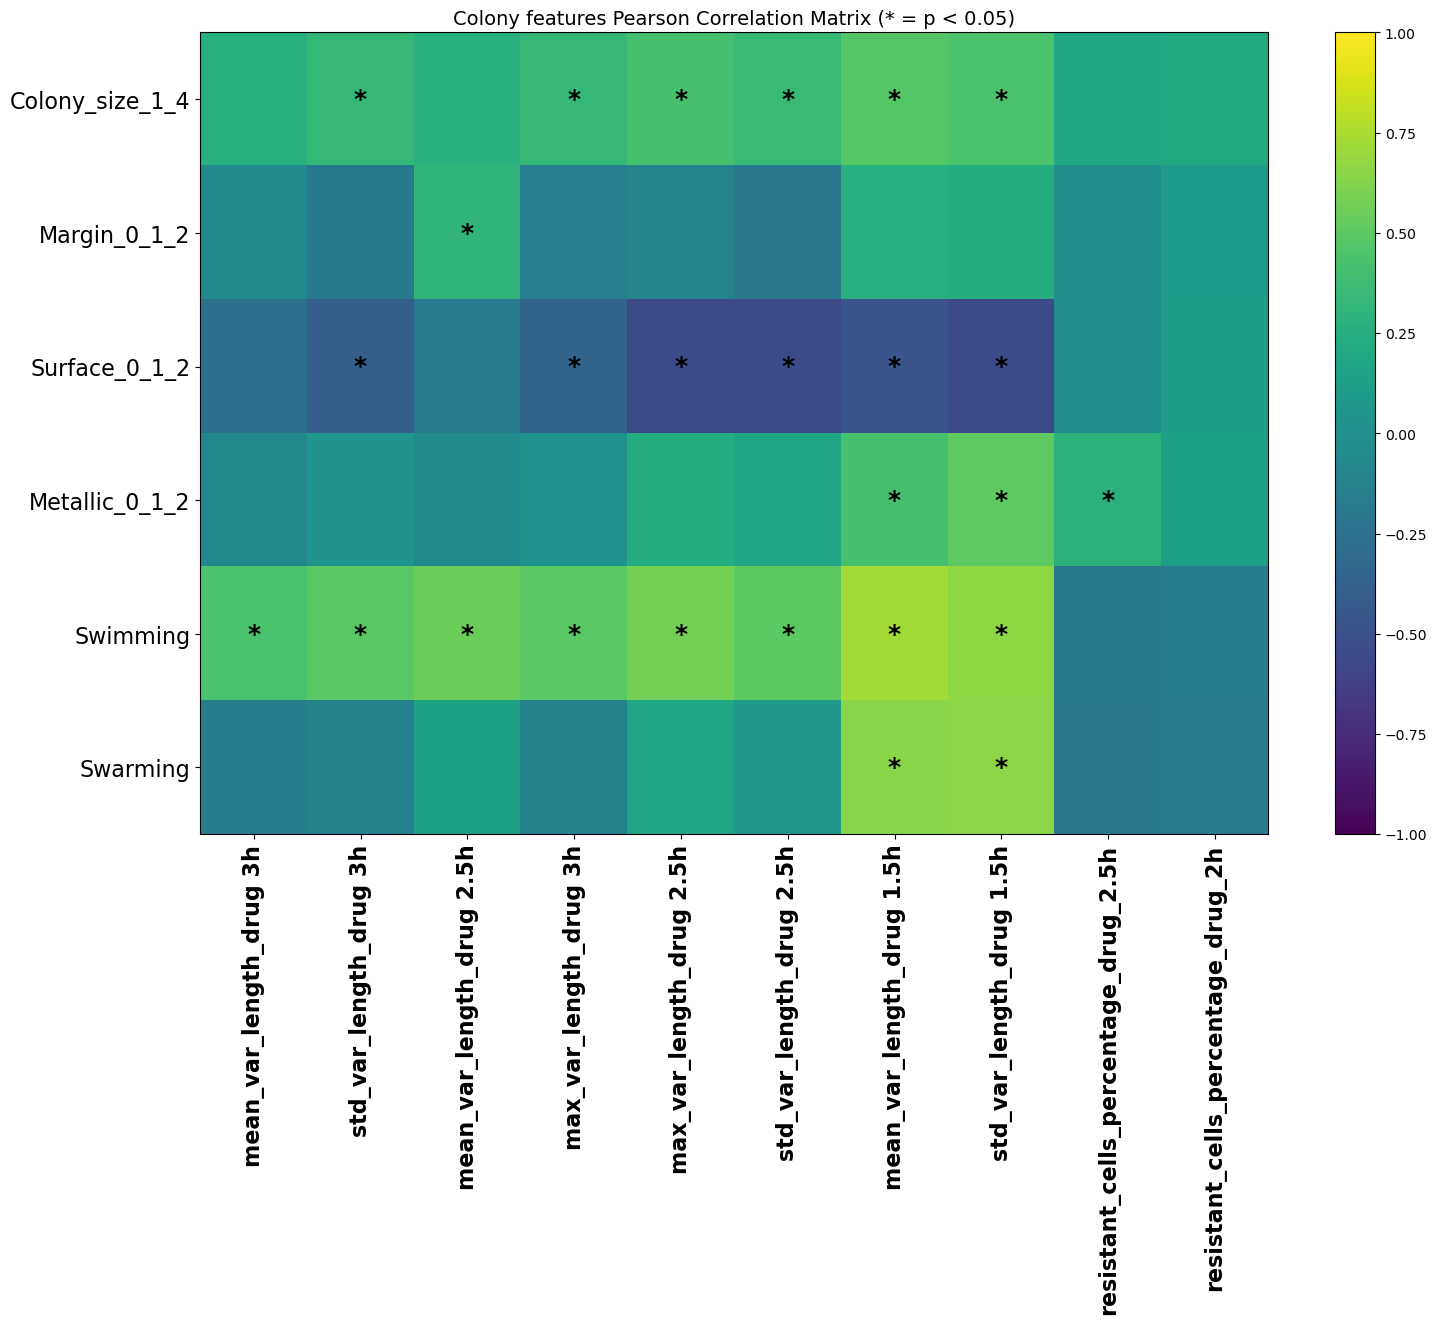

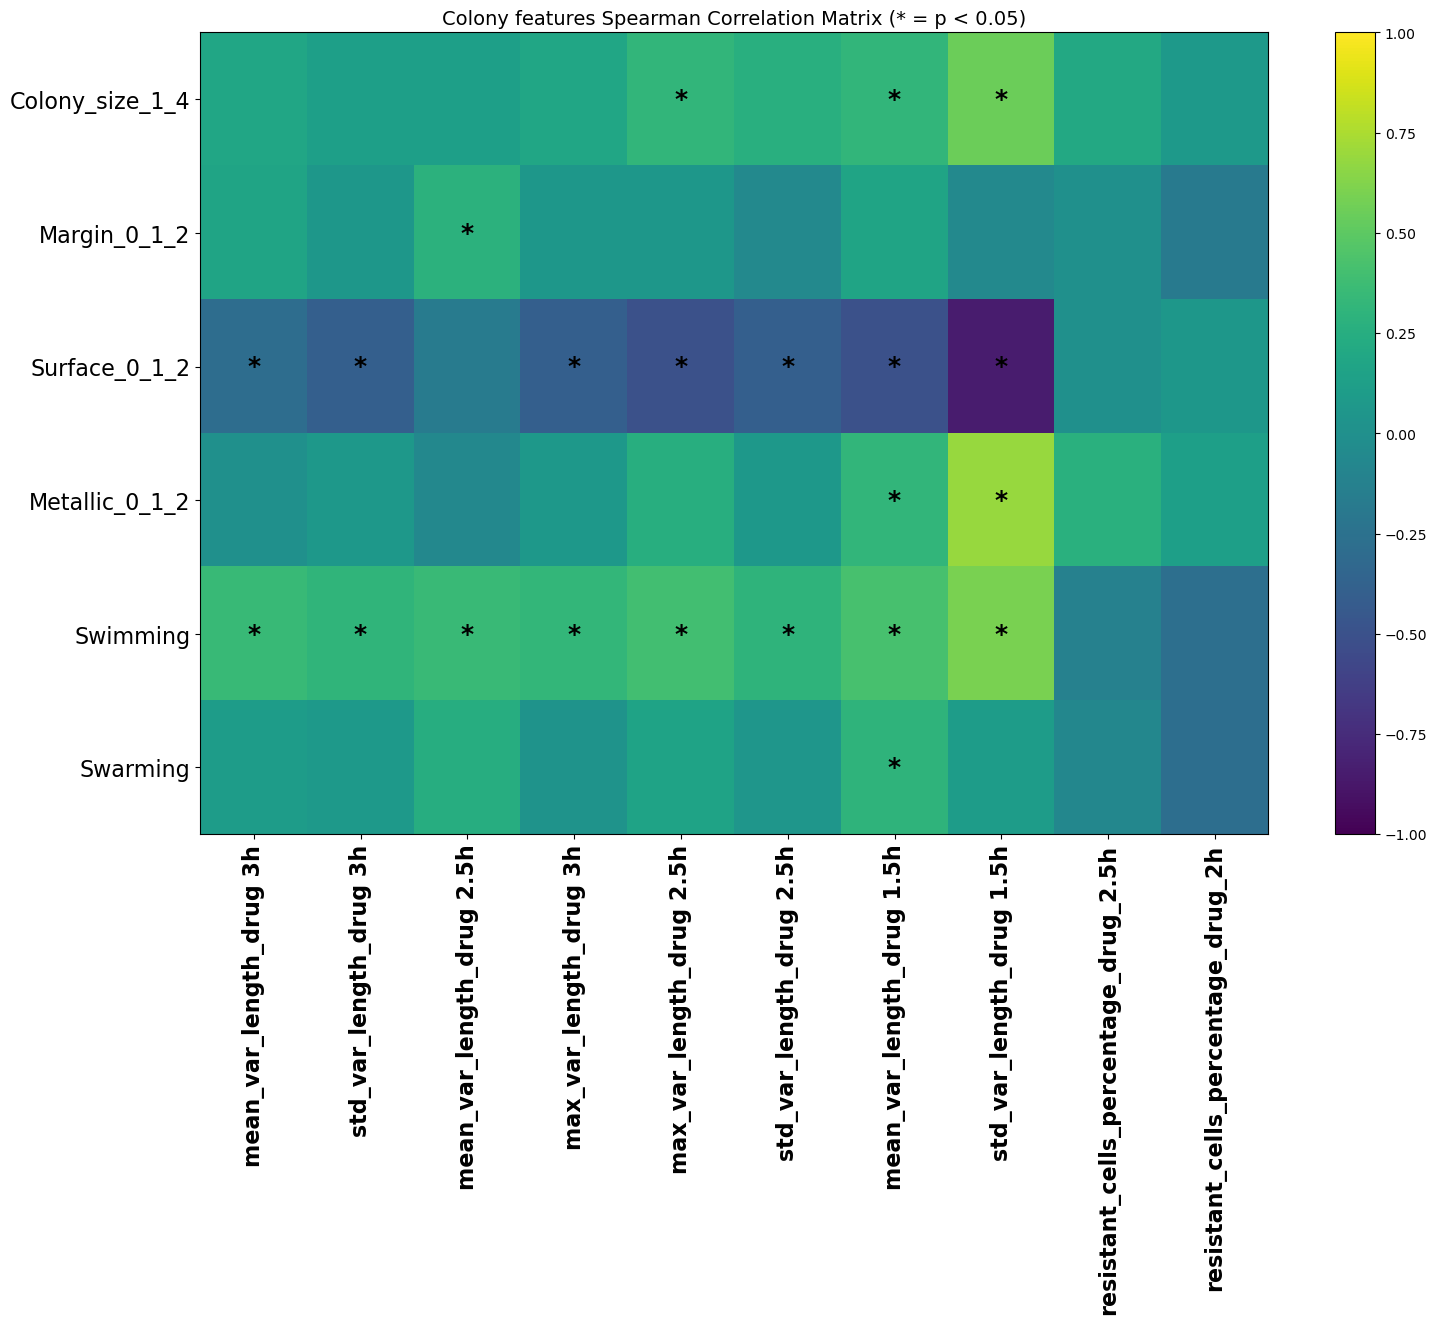

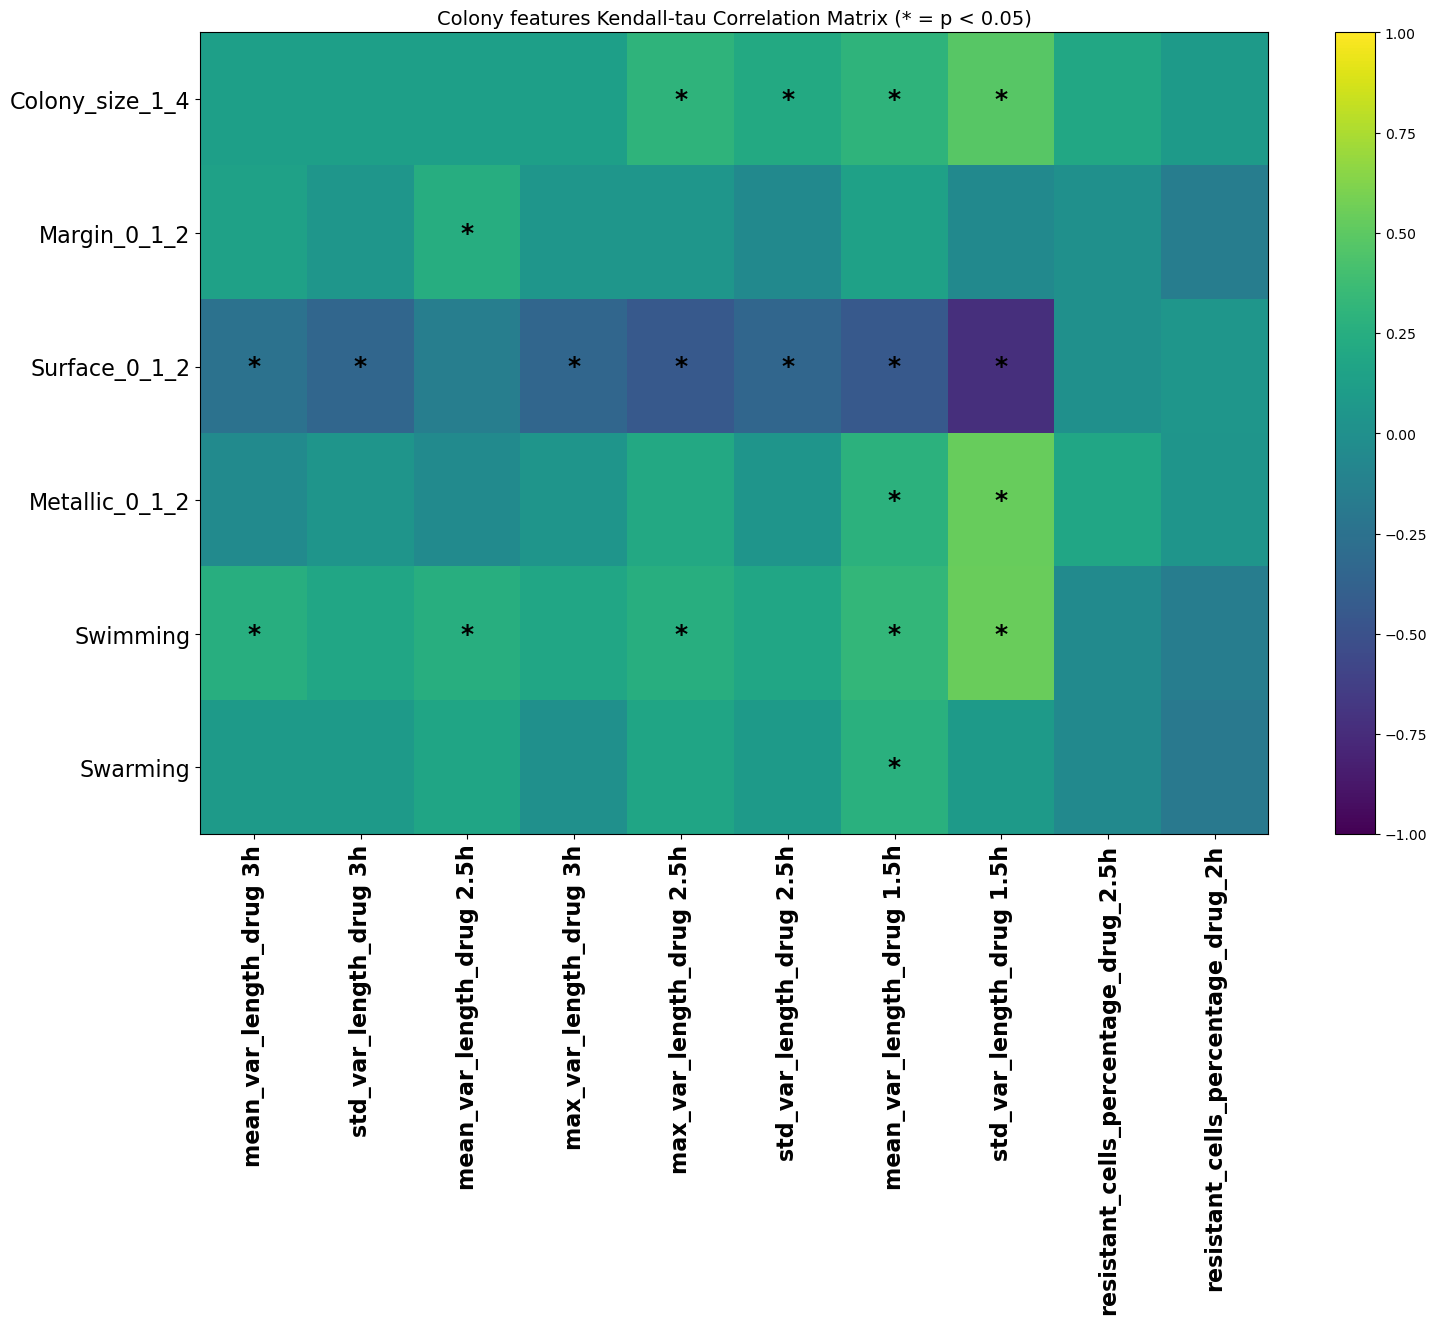

In [88]:
corr_pear, pvals_pear = compute_corr_and_p(phenotypic, microfluidics_features, method='pearson')
corr_spear, pvals_spear = compute_corr_and_p(phenotypic, microfluidics_features, method='spearman')
corr_kendall, pvals_kendall = compute_corr_and_p(phenotypic, microfluidics_features, method='kendall')


plot_corr_with_sig_imshow(
    corr=corr_pear,
    pvals=pvals_pear,
    title="Colony features Pearson Correlation Matrix (* = p < 0.05)",
    filename="phenotypic_pear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_spear,
    pvals=pvals_spear,
    title="Colony features Spearman Correlation Matrix (* = p < 0.05)",
    filename="phenotypic_spear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_kendall,
    pvals=pvals_kendall,
    title="Colony features Kendall-tau Correlation Matrix (* = p < 0.05)",
    filename="phenotypic_kendall_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)


# MIC 

In [89]:


# 2. Filter and reorder rows by df_nanomotion['strain_name']
ordered = df_phenotypic.set_index('strain').loc[df['strain_name']]

# 3. Keep only the first row of every 3 rows (0, 3, 6, ...)
ordered = ordered.iloc[::3, :]

# 4. Add 'strain' as first column + selected phenotypic columns
final_cols = ['CIP']

# 5. Final result
mic = ordered.reset_index()[final_cols]

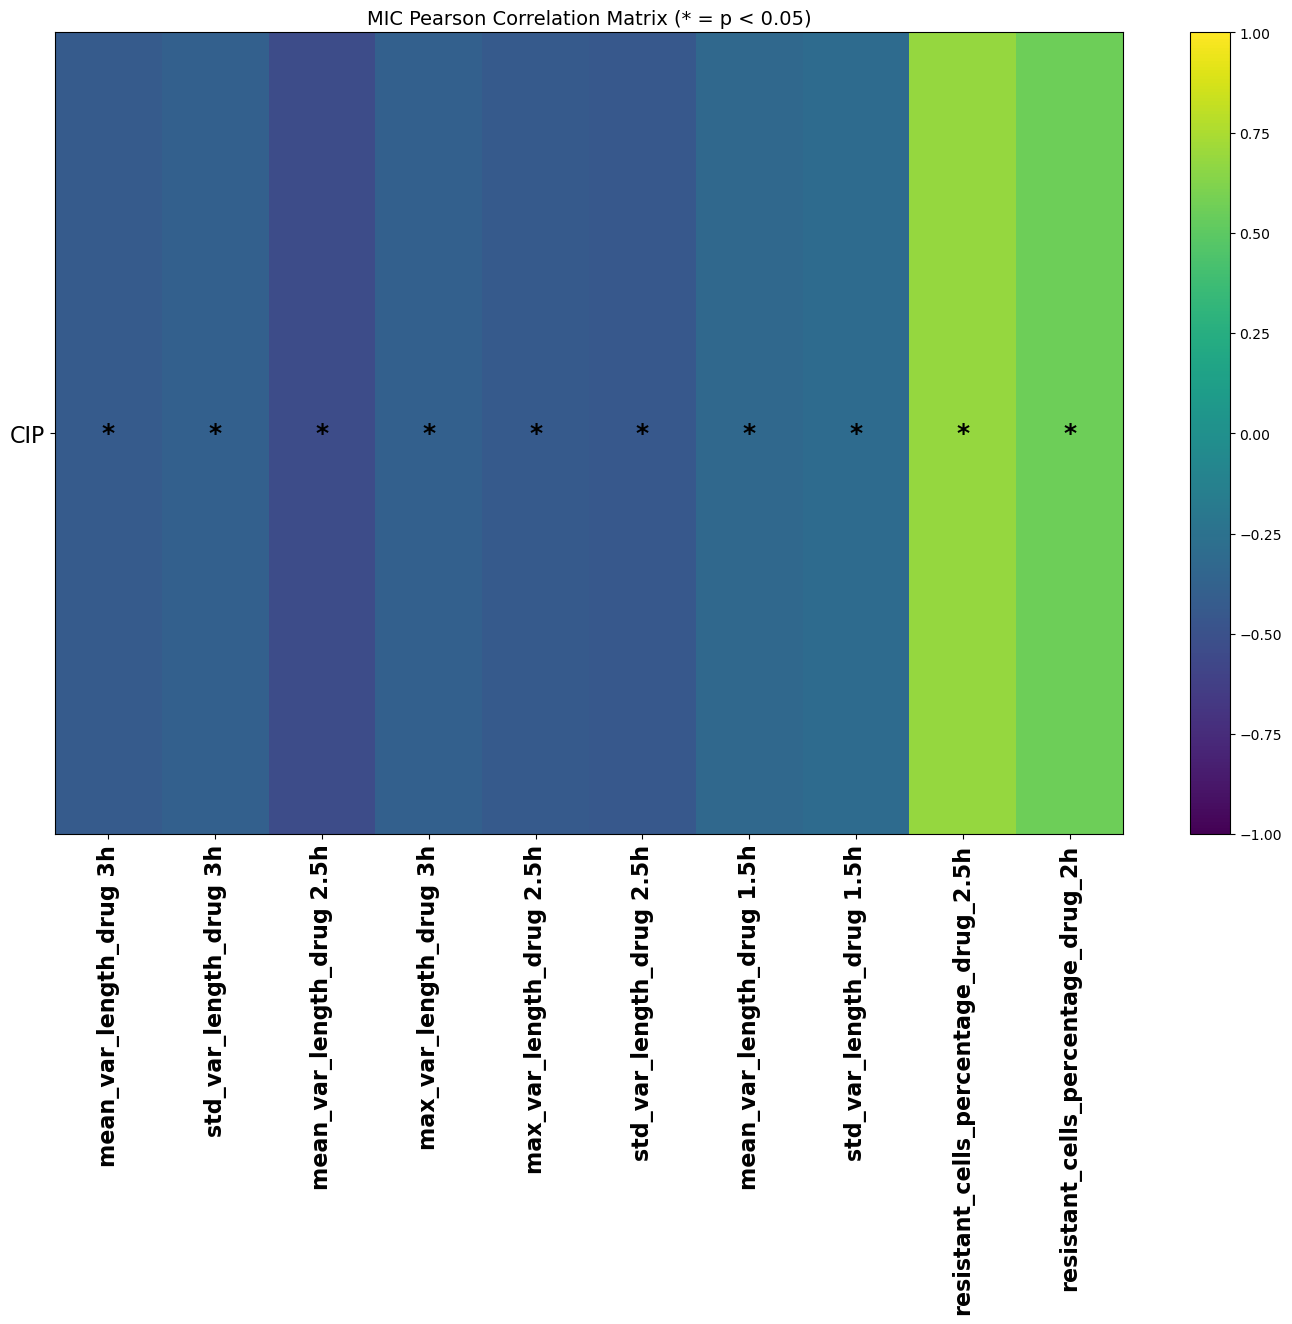

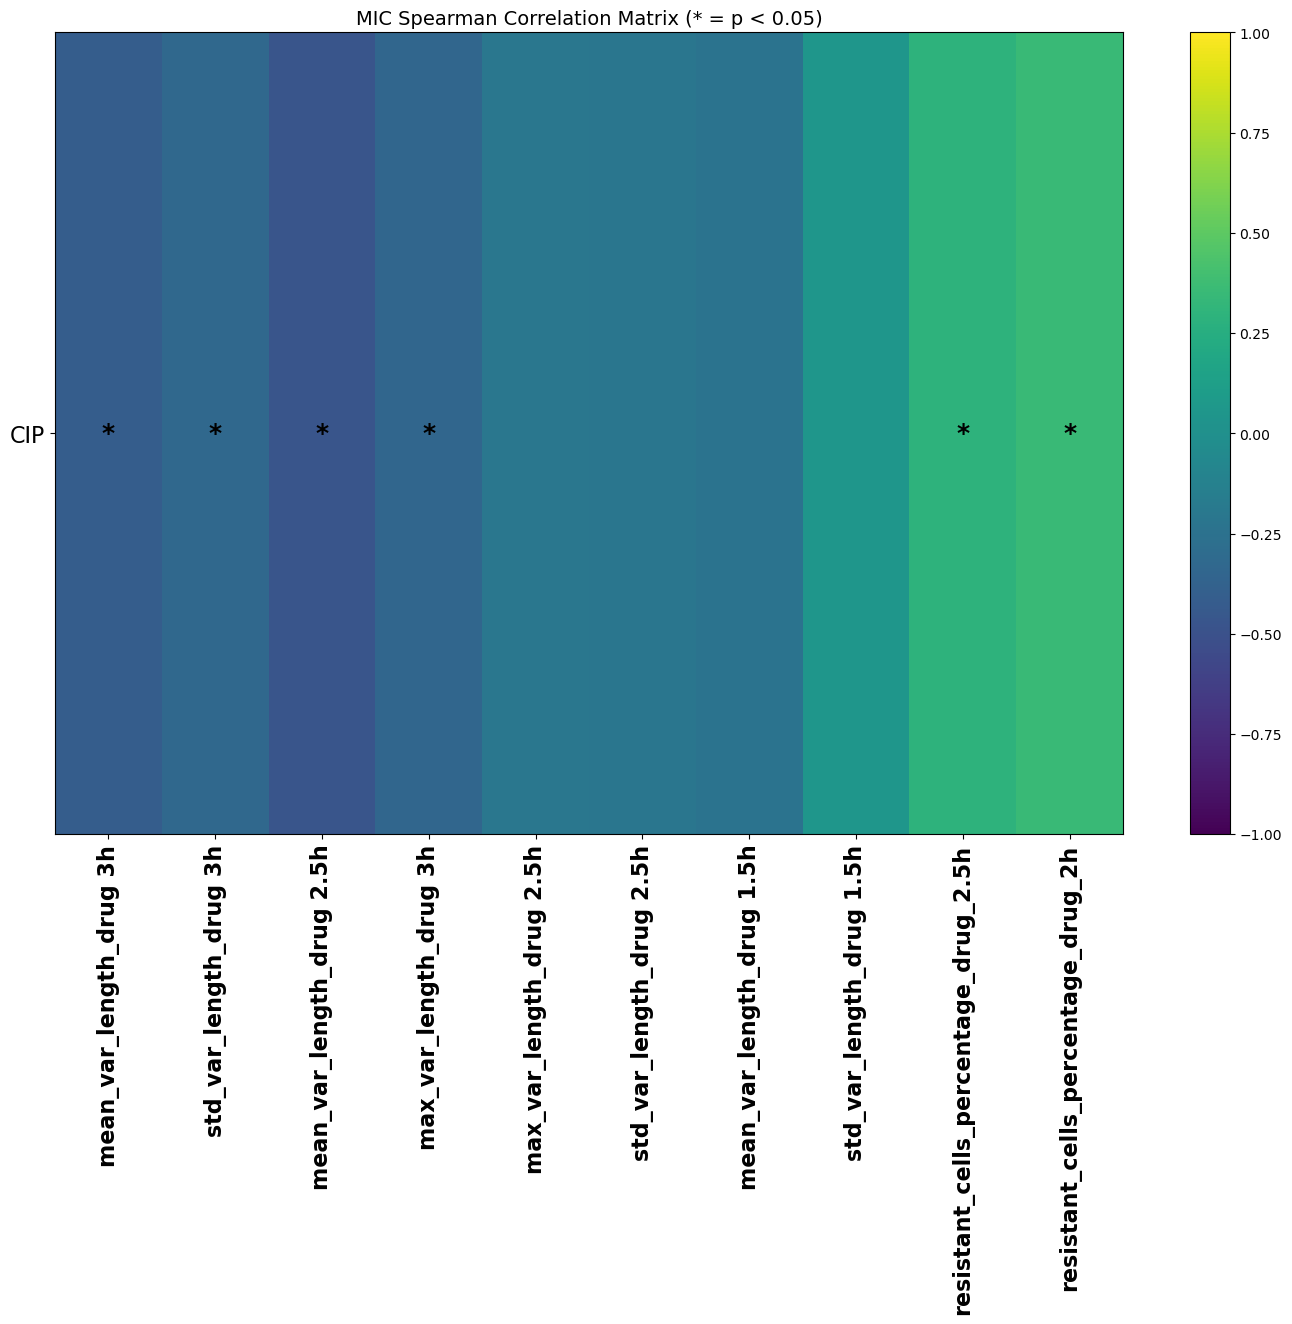

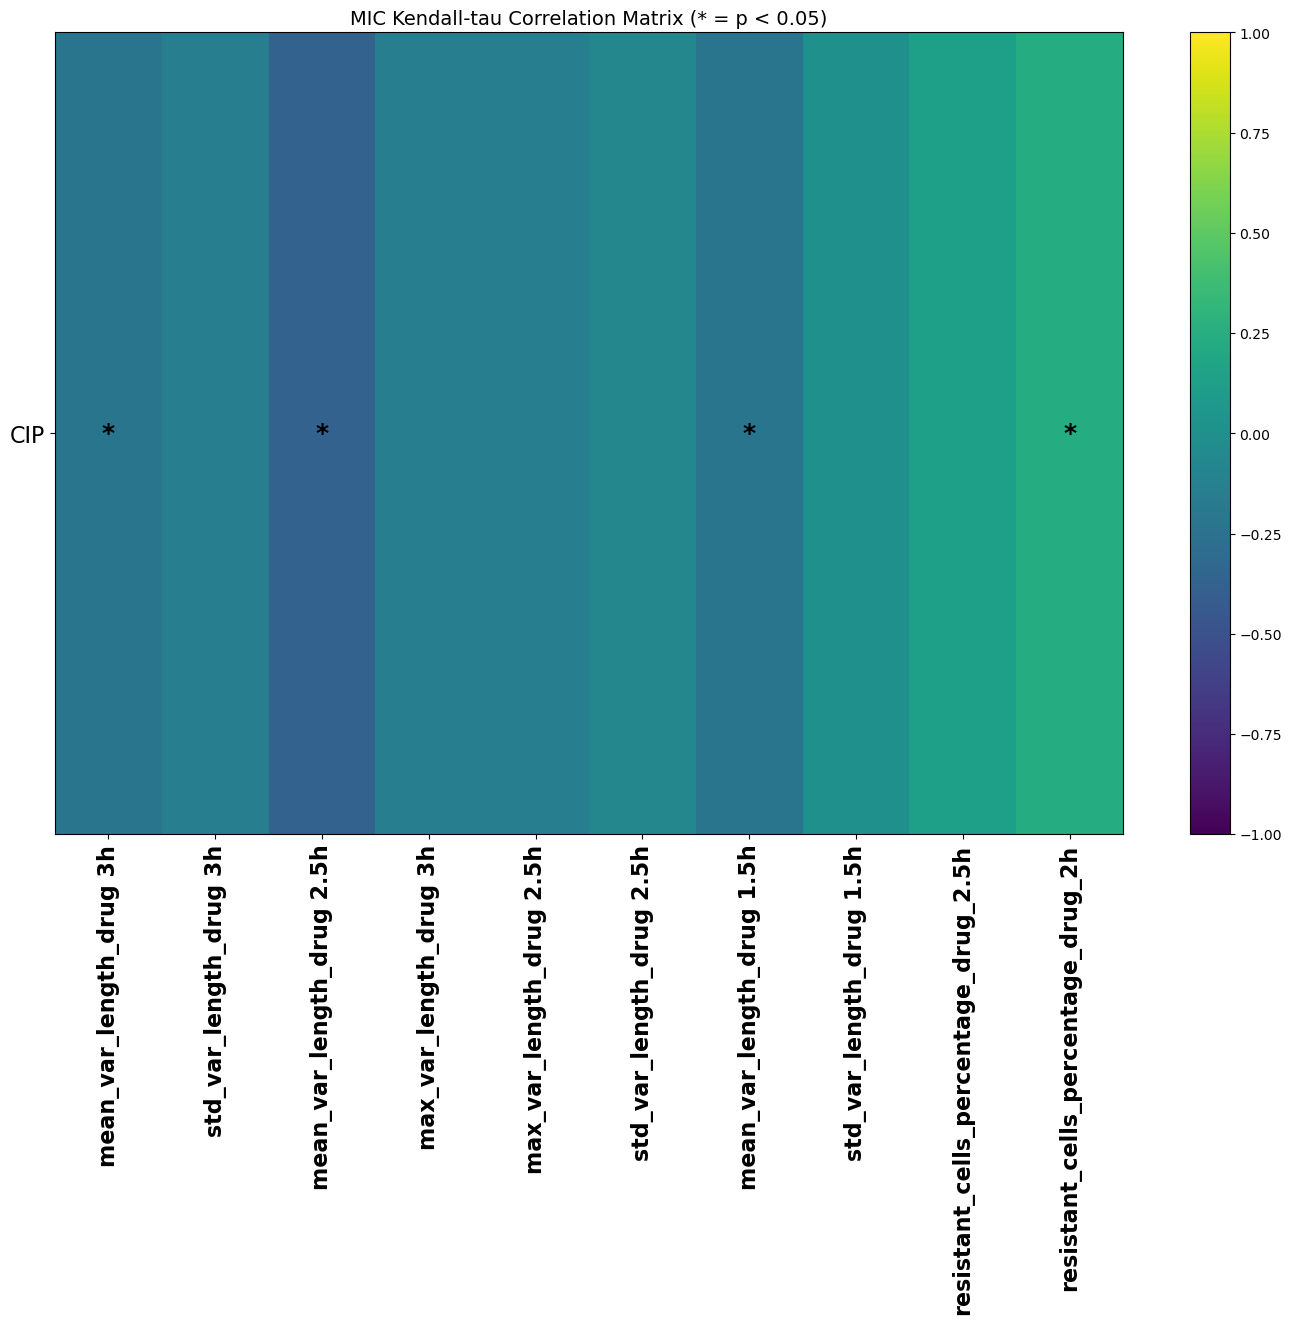

In [90]:
corr_pear, pvals_pear = compute_corr_and_p(mic, microfluidics_features, method='pearson')
corr_spear, pvals_spear = compute_corr_and_p(mic, microfluidics_features, method='spearman')
corr_kendall, pvals_kendall = compute_corr_and_p(mic, microfluidics_features, method='kendall')


plot_corr_with_sig_imshow(
    corr=corr_pear,
    pvals=pvals_pear,
    title="MIC Pearson Correlation Matrix (* = p < 0.05)",
    filename="mic_pear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_spear,
    pvals=pvals_spear,
    title="MIC Spearman Correlation Matrix (* = p < 0.05)",
    filename="mic_spear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_kendall,
    pvals=pvals_kendall,
    title="MIC Kendall-tau Correlation Matrix (* = p < 0.05)",
    filename="mic_kendall_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)


## Virulence

In [198]:
# 2. Filter and reorder rows by df_nanomotion['strain_name']
ordered = df_phenotypic.set_index('strain').loc[df['strain_name']]

# 3. Keep only the first of every 3 duplicate rows
ordered = ordered.iloc[::3, :]

# 4. Select columns X–Z (0-indexed positions 23, 24, 25)
final_cols = [23, 24, 25]

# 5. Extract these columns correctly
virulence = ordered.reset_index().iloc[:, final_cols]


In [199]:
virulence

,Hemolysis_0_1_2,Survival_24,Survival_48
0,0.0,95.000000,85.000000
1,1.0,80.000000,5.000000
2,0.0,NaN,NaN
3,2.0,100.000000,60.000000
4,1.0,NaN,NaN
5,2.0,95.000000,85.000000
6,2.0,0.000000,0.000000
7,1.0,95.000000,75.000000
8,1.0,13.333333,3.333333
9,2.0,0.000000,0.000000


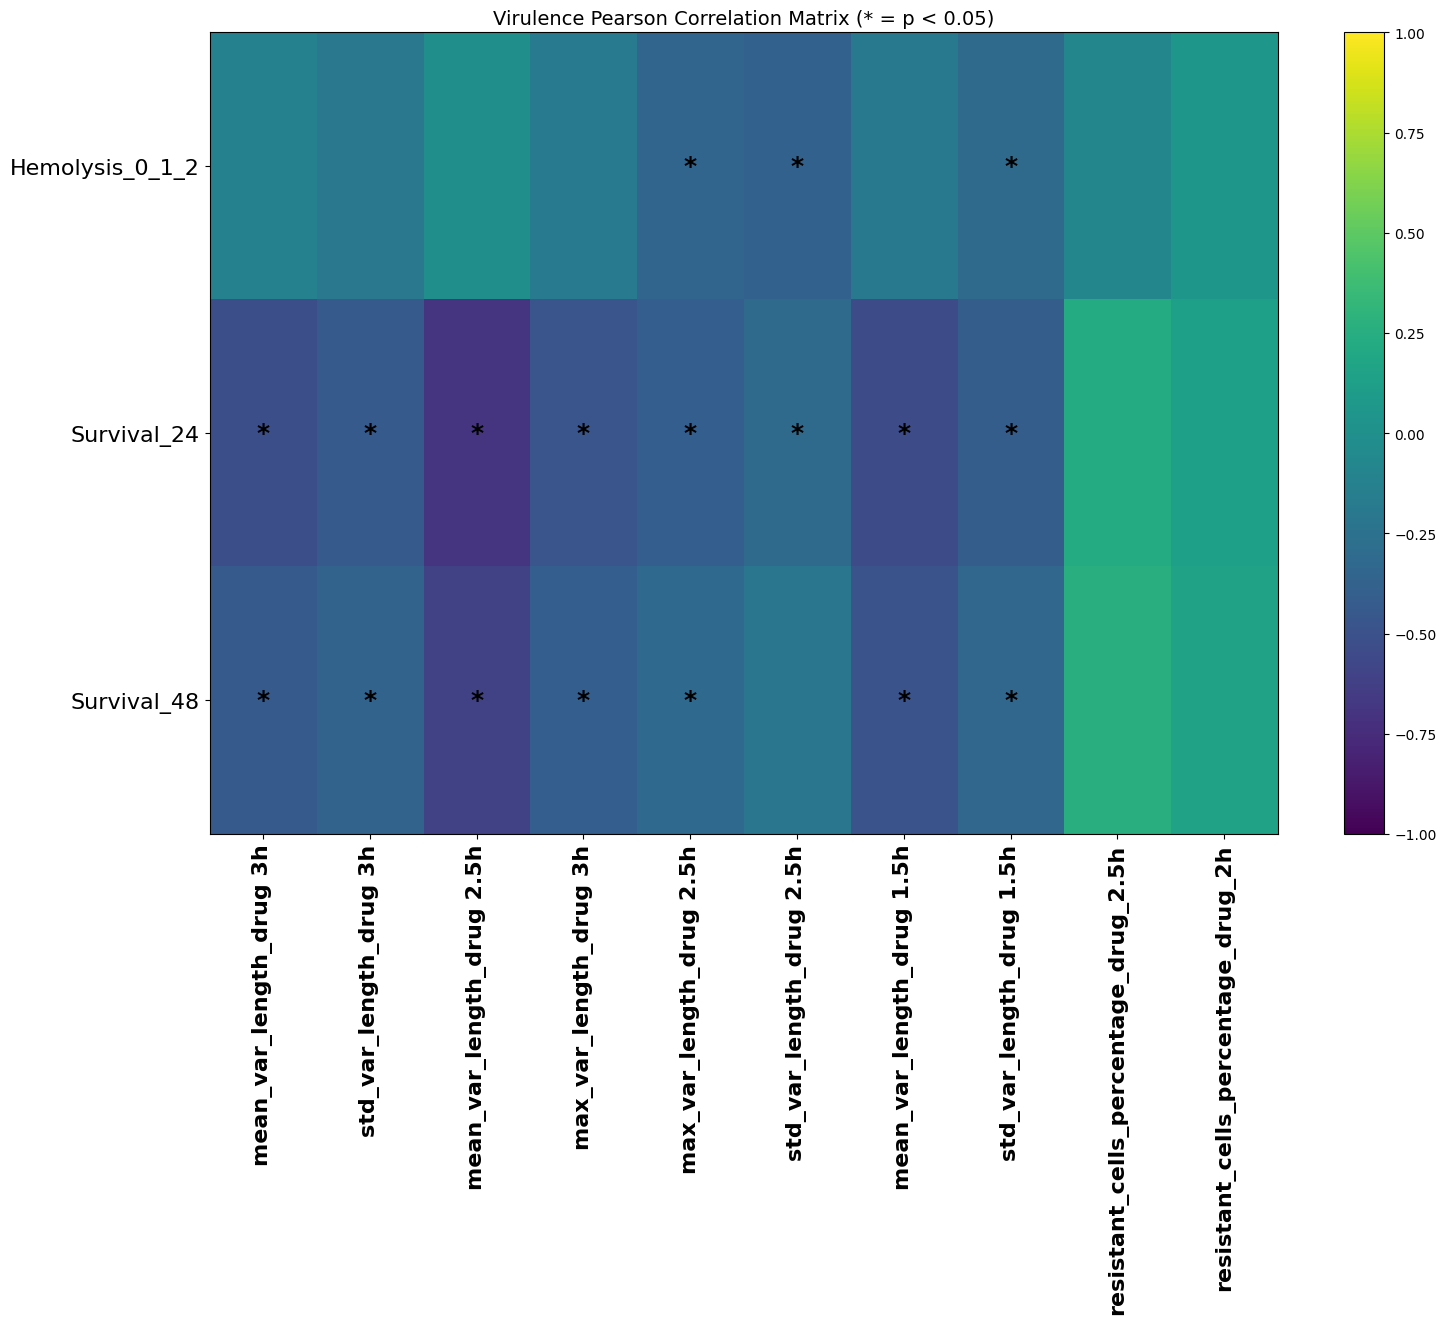

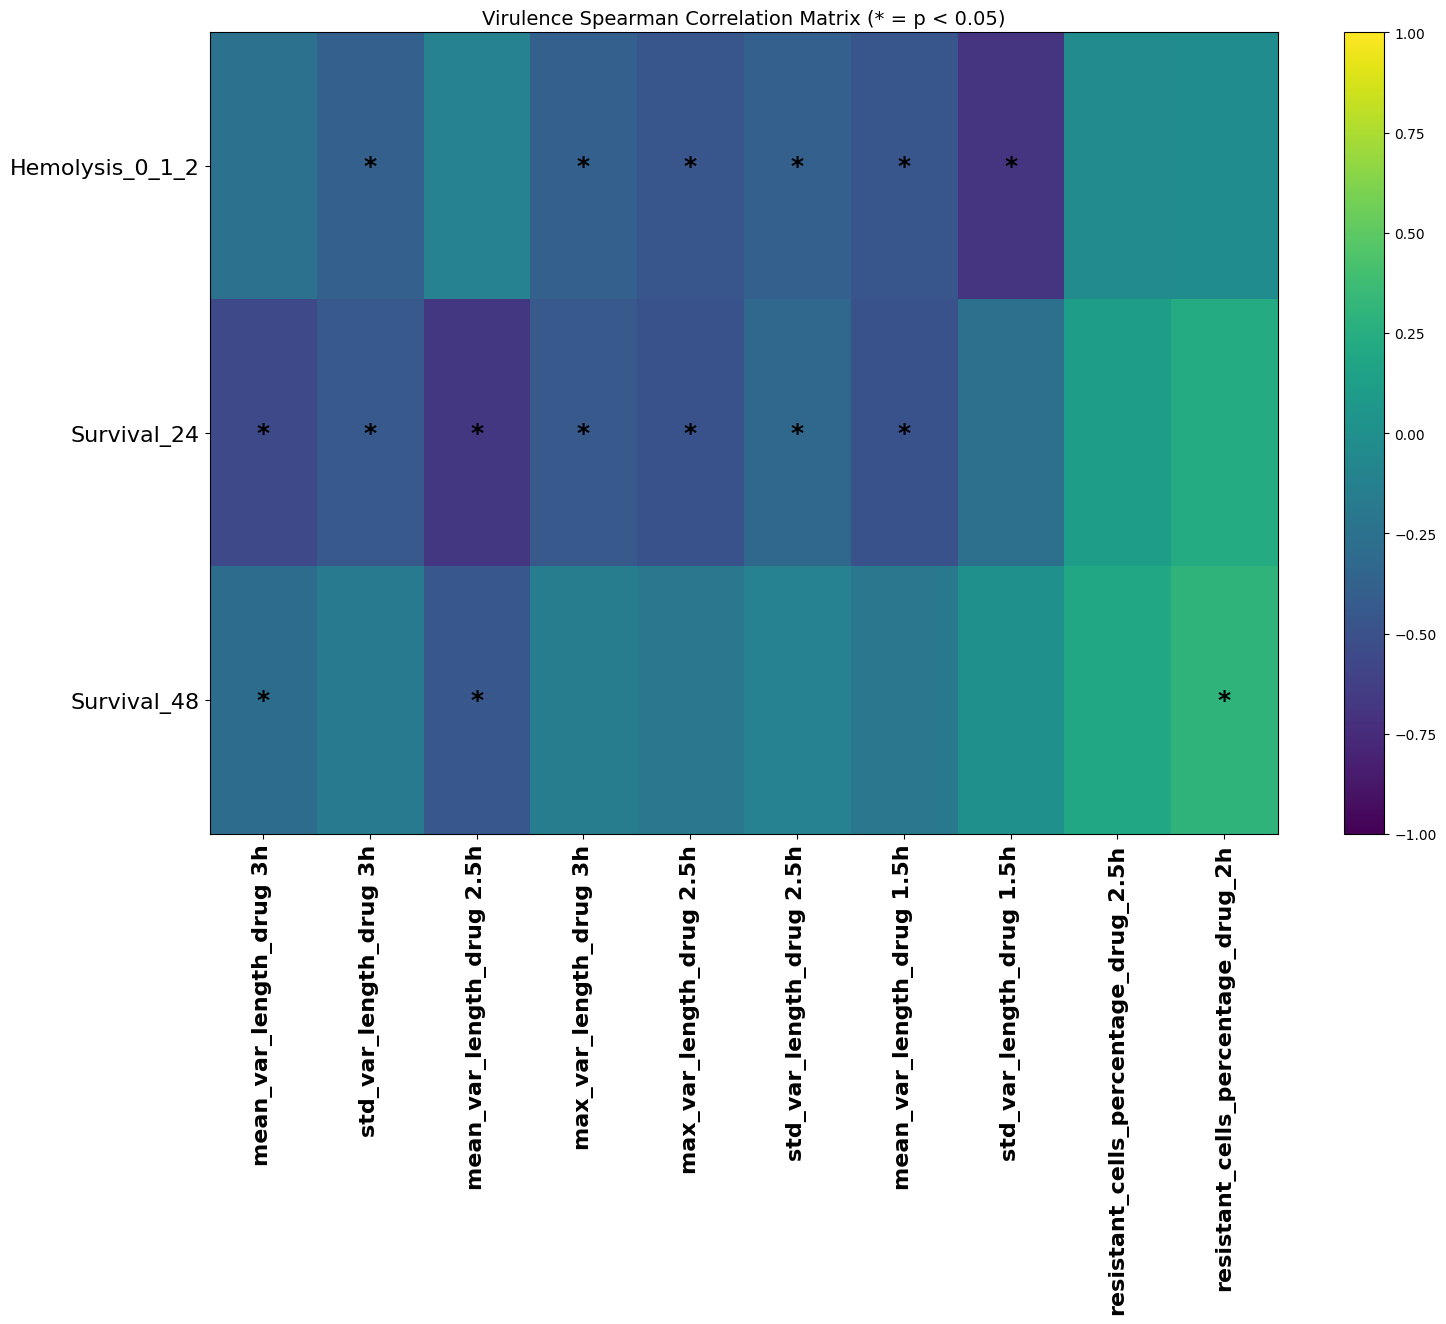

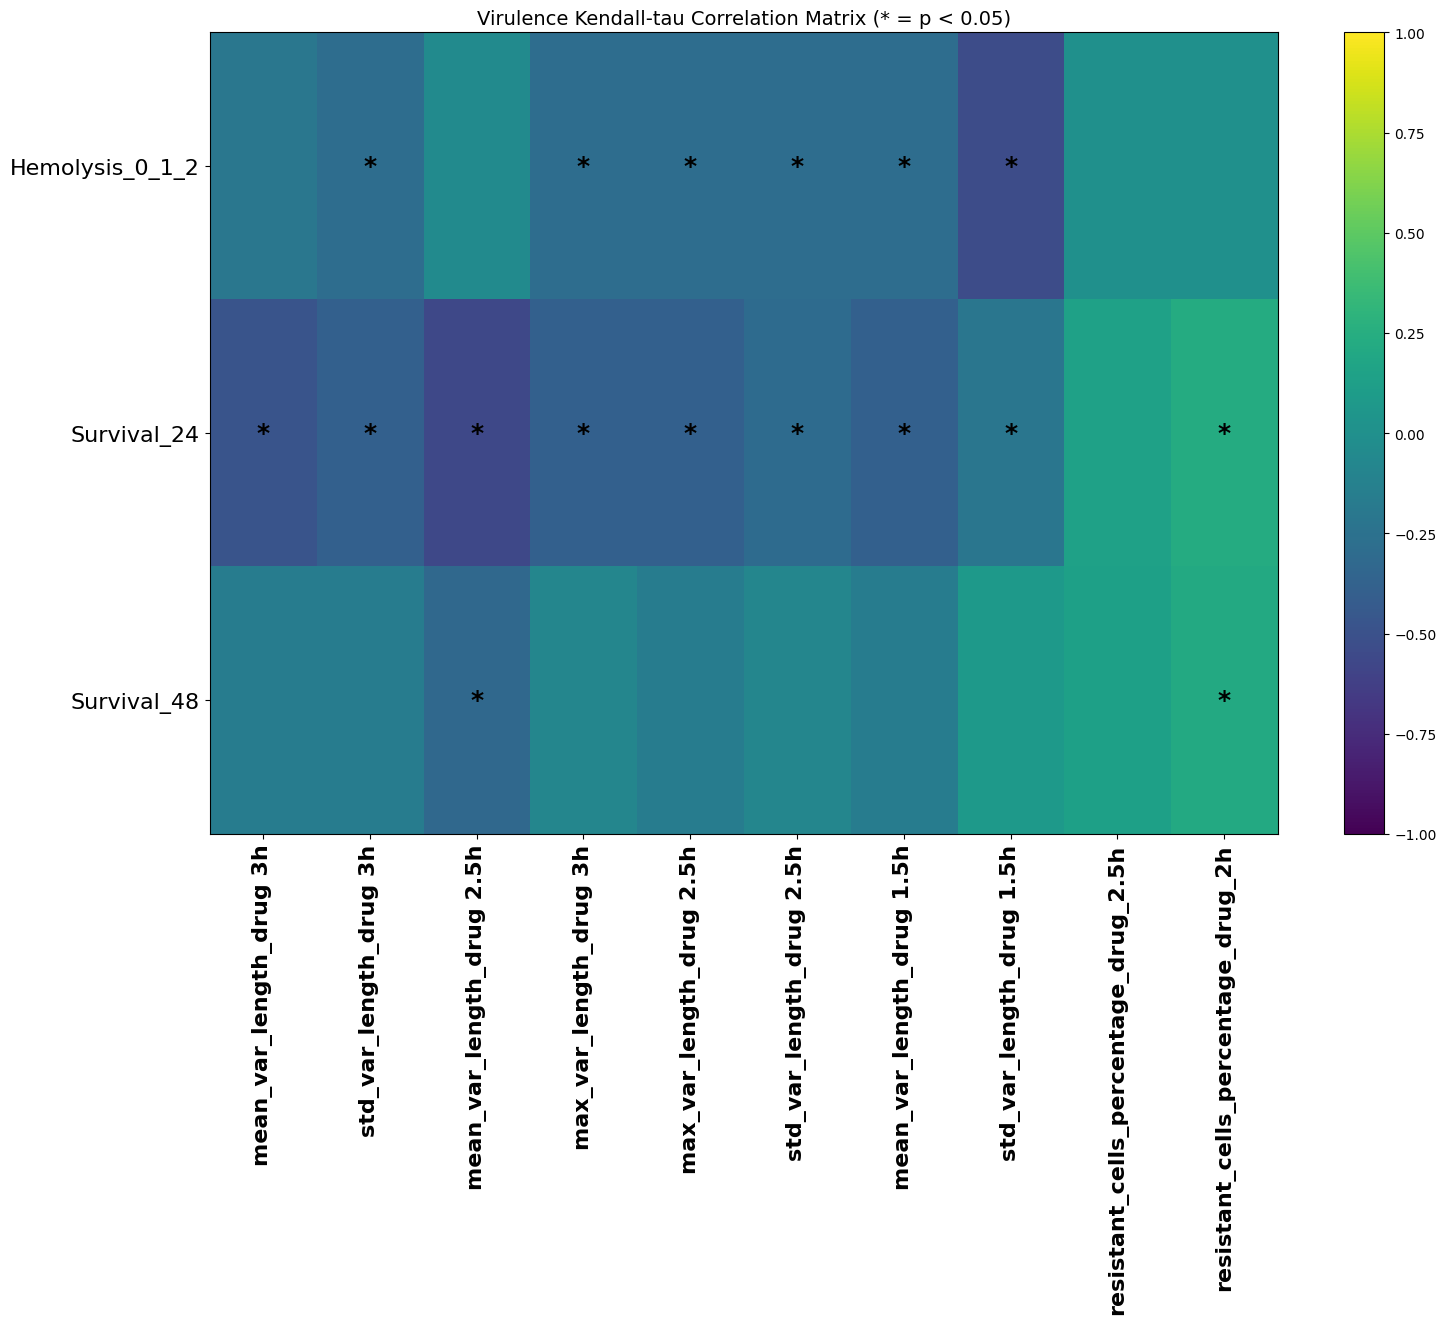

In [200]:
corr_pear, pvals_pear = compute_corr_and_p(virulence, microfluidics_features, method='pearson')
corr_spear, pvals_spear = compute_corr_and_p(virulence, microfluidics_features, method='spearman')
corr_kendall, pvals_kendall = compute_corr_and_p(virulence, microfluidics_features, method='kendall')


plot_corr_with_sig_imshow(
    corr=corr_pear,
    pvals=pvals_pear,
    title="Virulence Pearson Correlation Matrix (* = p < 0.05)",
    filename="virulence_pear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_spear,
    pvals=pvals_spear,
    title="Virulence Spearman Correlation Matrix (* = p < 0.05)",
    filename="virulence_spear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_kendall,
    pvals=pvals_kendall,
    title="Virulence Kendall-tau Correlation Matrix (* = p < 0.05)",
    filename="virulence_kendall_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)


## Imunne response

In [201]:
def col_letter_to_index(col):
    """Convert Excel column letters to 0-indexed column index."""
    col = col.upper()
    num = 0
    for c in col:
        num = num * 26 + (ord(c) - ord('A') + 1)
    return num - 1   # convert to 0-indexed


In [202]:
# Filter and reorder rows by df['strain_name']
ordered = df_phenotypic.set_index('strain').loc[df['strain_name']]

# Keep only first of every 3 duplicates
ordered = ordered.iloc[::3, :]


In [203]:
start = col_letter_to_index("AI")   # inclusive
end   = col_letter_to_index("BD")   # inclusive


In [204]:
immune_response = ordered.reset_index().iloc[:, start : end + 1]


In [205]:

# immune_response

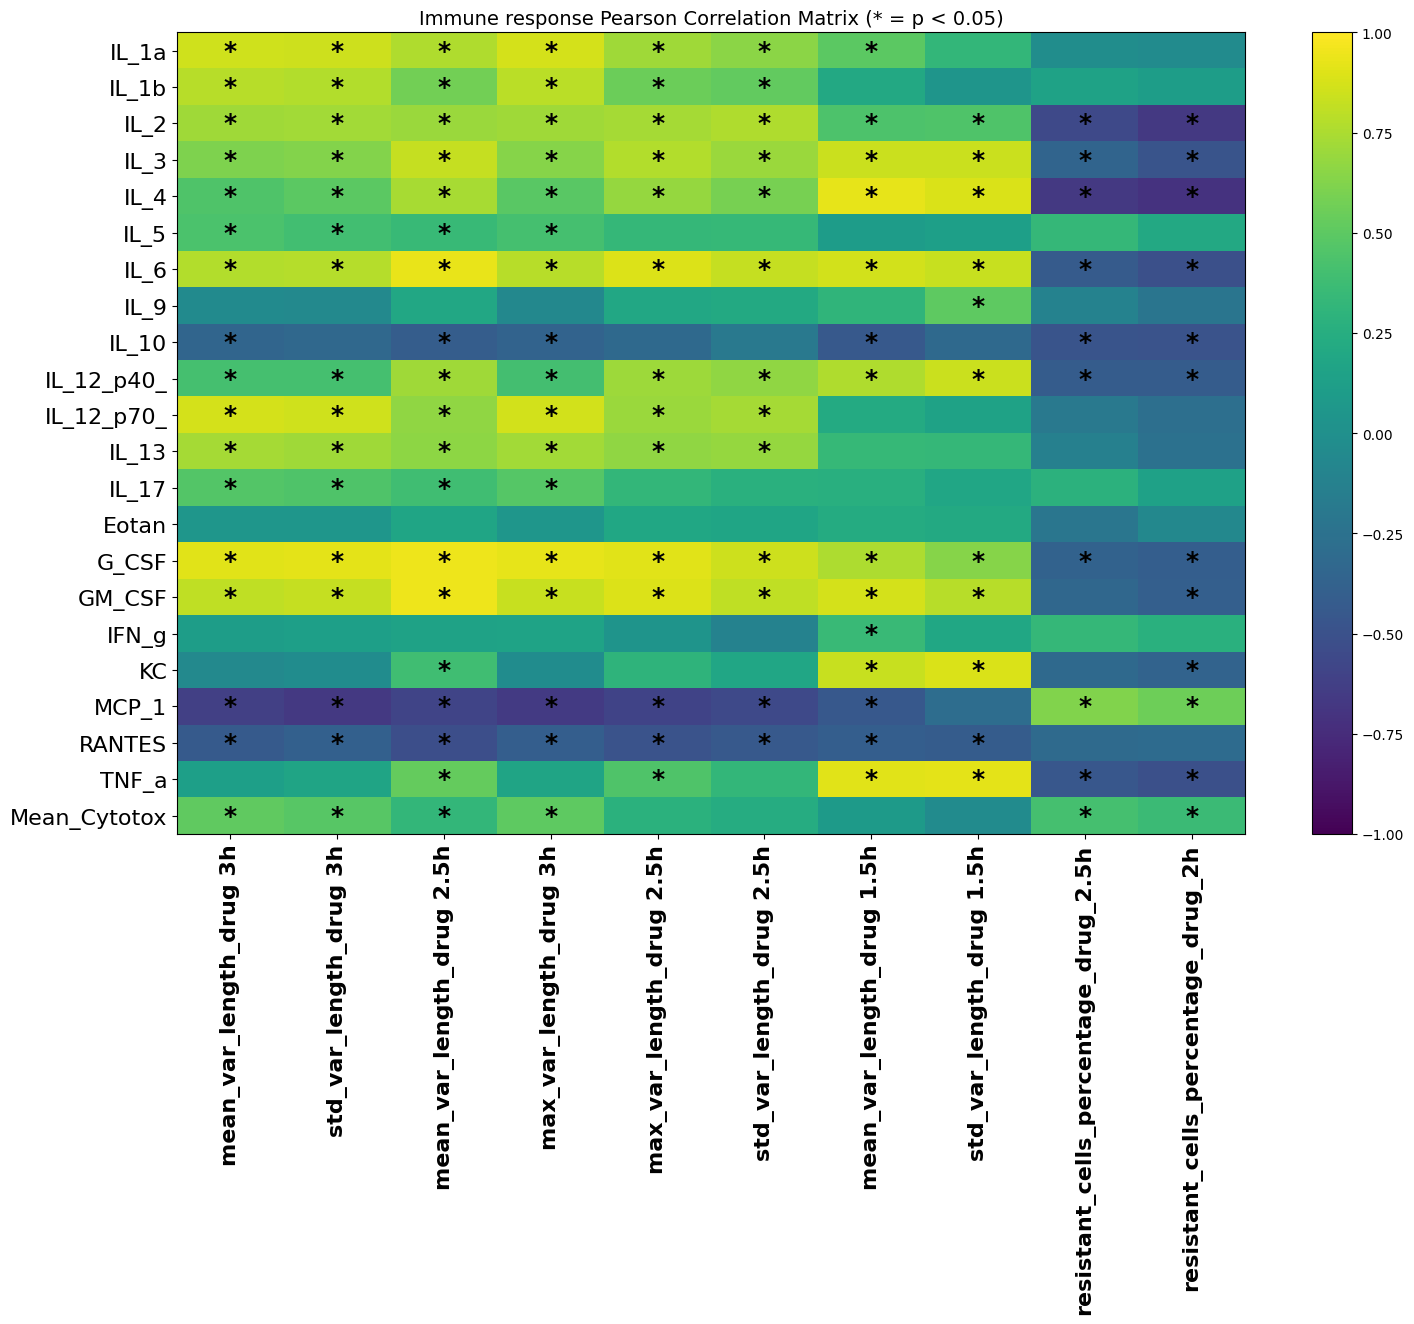

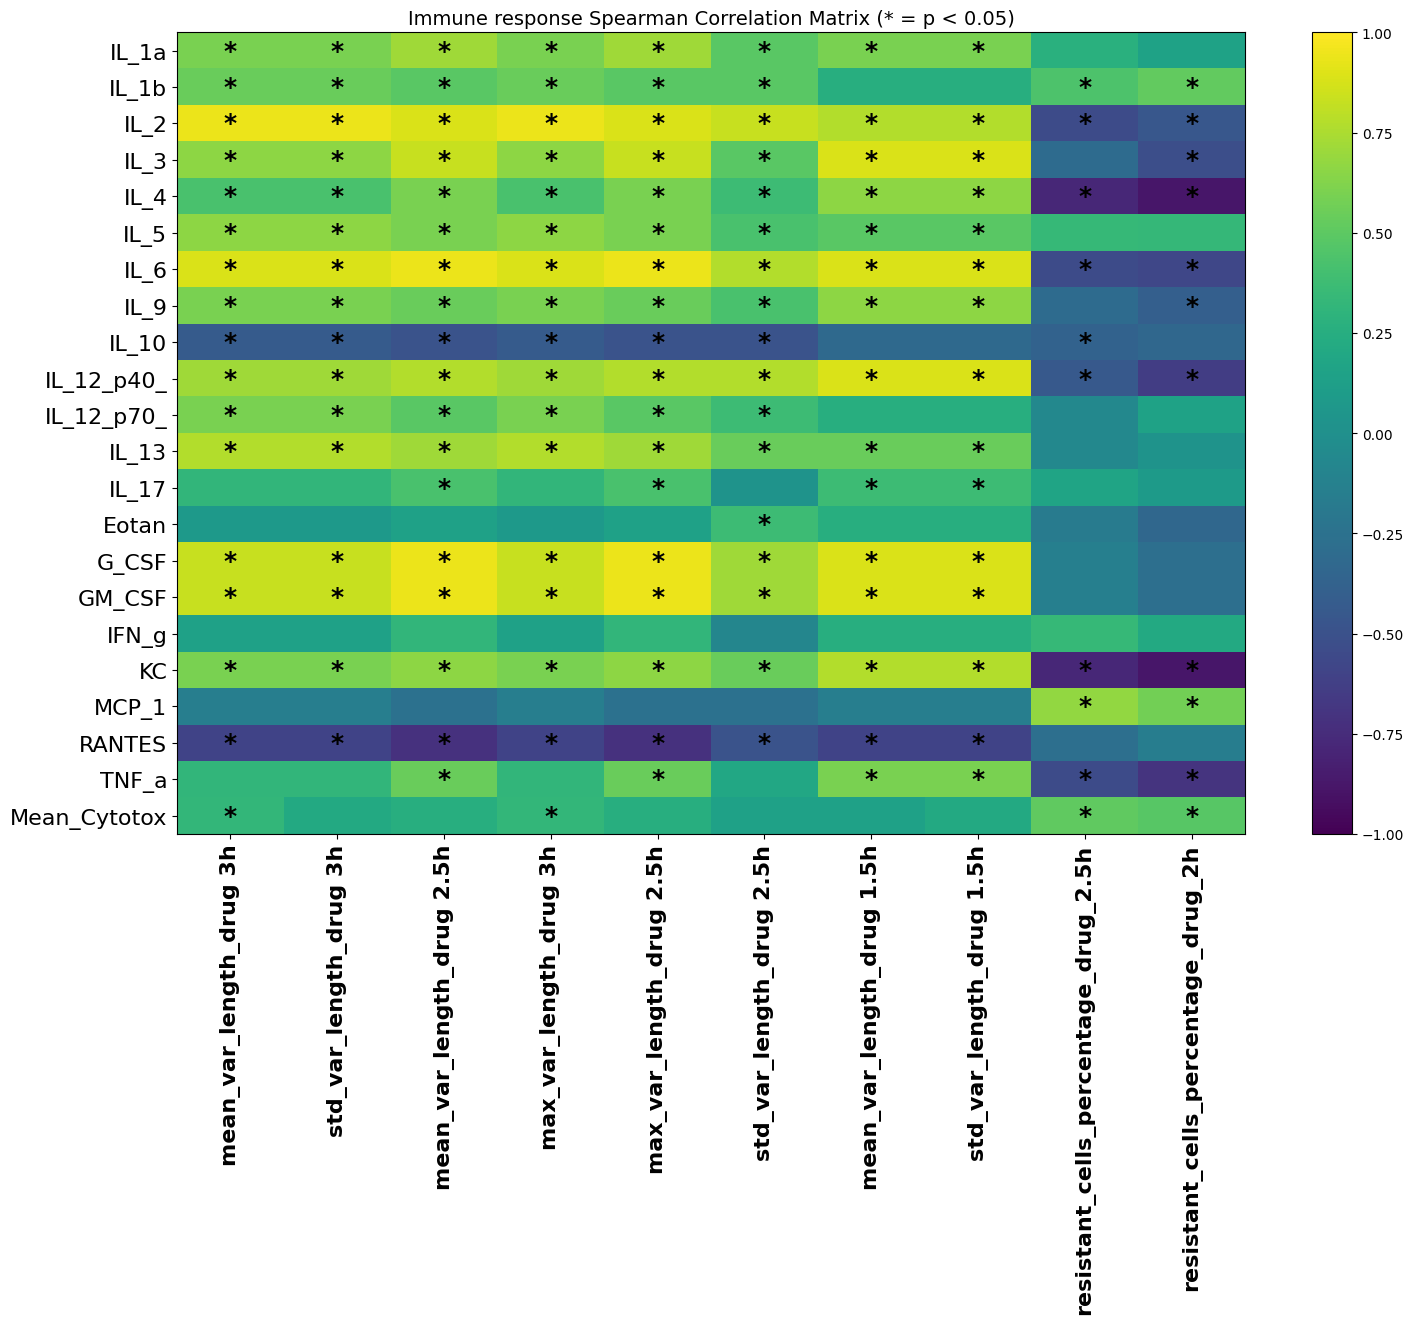

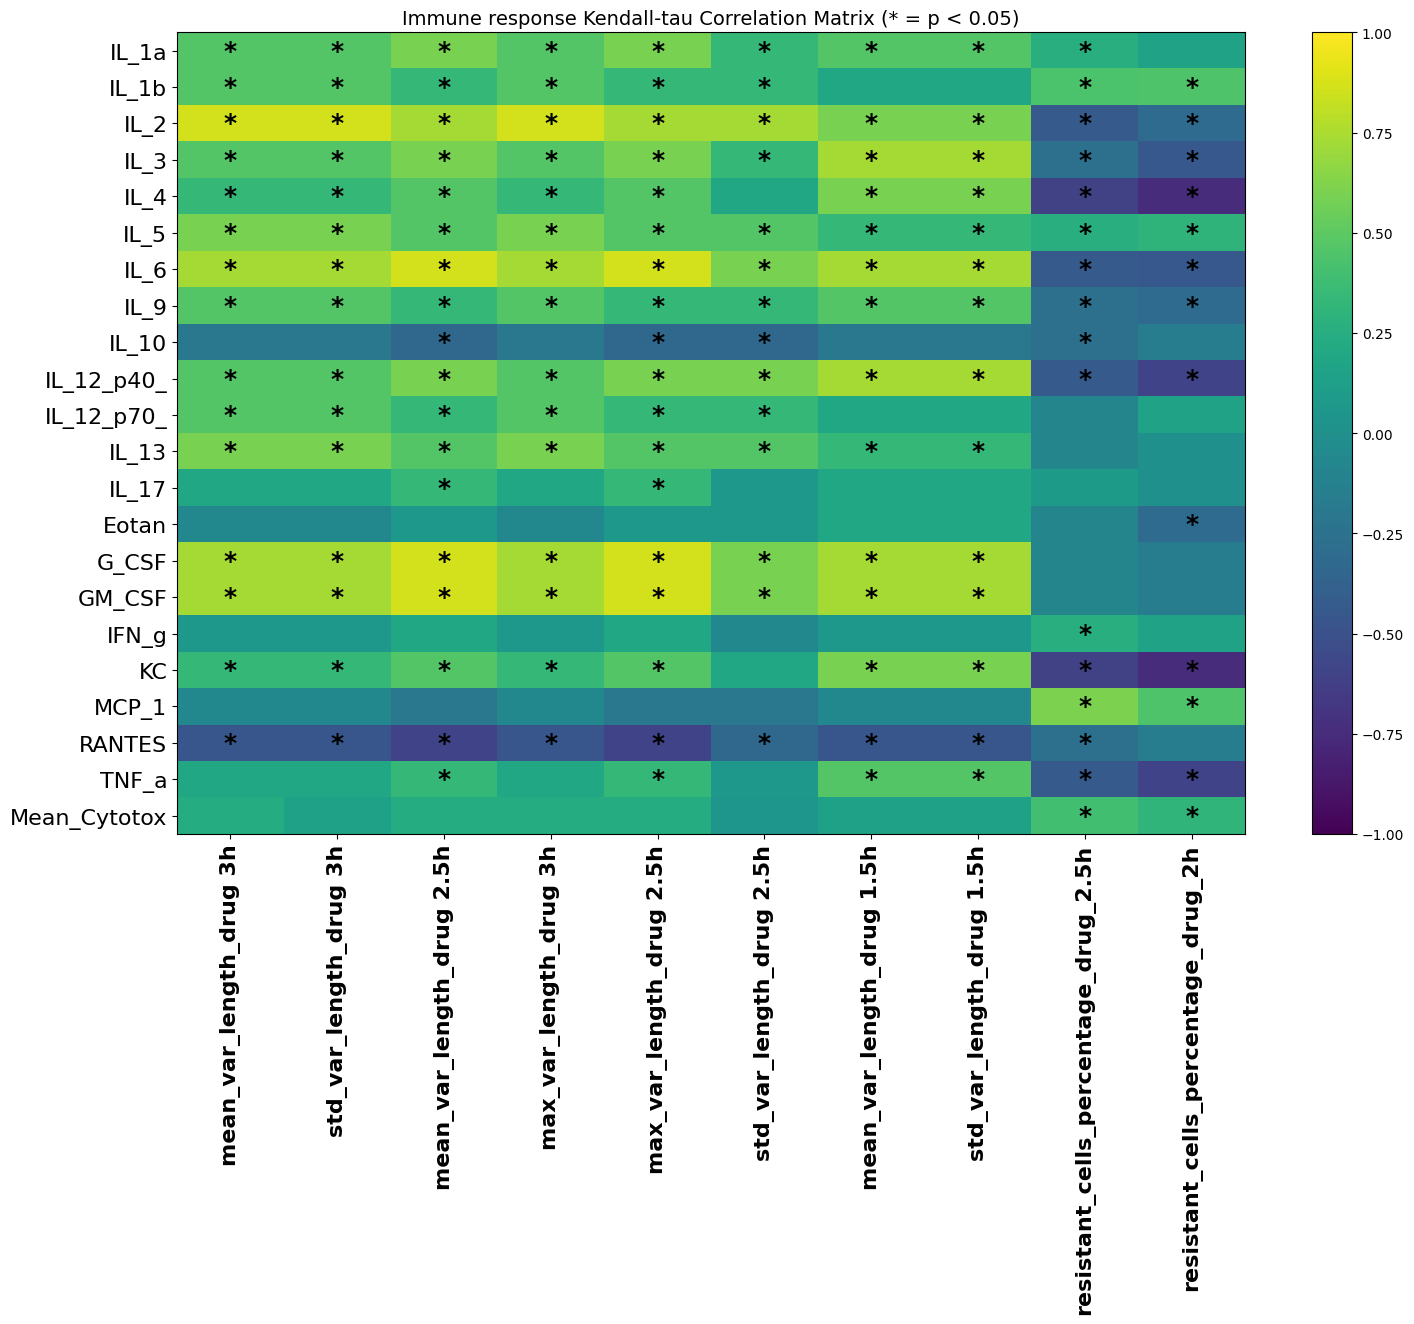

In [206]:
corr_pear, pvals_pear = compute_corr_and_p(immune_response, microfluidics_features, method='pearson')
corr_spear, pvals_spear = compute_corr_and_p(immune_response, microfluidics_features, method='spearman')
corr_kendall, pvals_kendall = compute_corr_and_p(immune_response, microfluidics_features, method='kendall')


plot_corr_with_sig_imshow(
    corr=corr_pear,
    pvals=pvals_pear,
    title="Immune response Pearson Correlation Matrix (* = p < 0.05)",
    filename="immune_response_pear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_spear,
    pvals=pvals_spear,
    title="Immune response Spearman Correlation Matrix (* = p < 0.05)",
    filename="immune_response_spear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_kendall,
    pvals=pvals_kendall,
    title="Immune response Kendall-tau Correlation Matrix (* = p < 0.05)",
    filename="phenotypic_kendall_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)


## Doubling time

In [207]:
# Doubling times
start = col_letter_to_index("BQ")
end   = col_letter_to_index("BR")


# Filter and reorder rows by df['strain_name']
ordered = df_phenotypic.set_index('strain').loc[df['strain_name']]

# Keep only first of every 3 duplicates
ordered = ordered.iloc[::3, :]


doubling_time = ordered.reset_index().iloc[:, start : end + 1]

In [208]:
doubling_time

,doubling_time,doubling_time_var
0,48.559,6.545
1,24.665,3.529
2,66.177,41.449
3,50.809,7.873
4,27.087,5.224
5,46.484,23.134
6,35.572,6.874
7,37.172,5.317
8,25.214,2.122
9,27.408,4.829


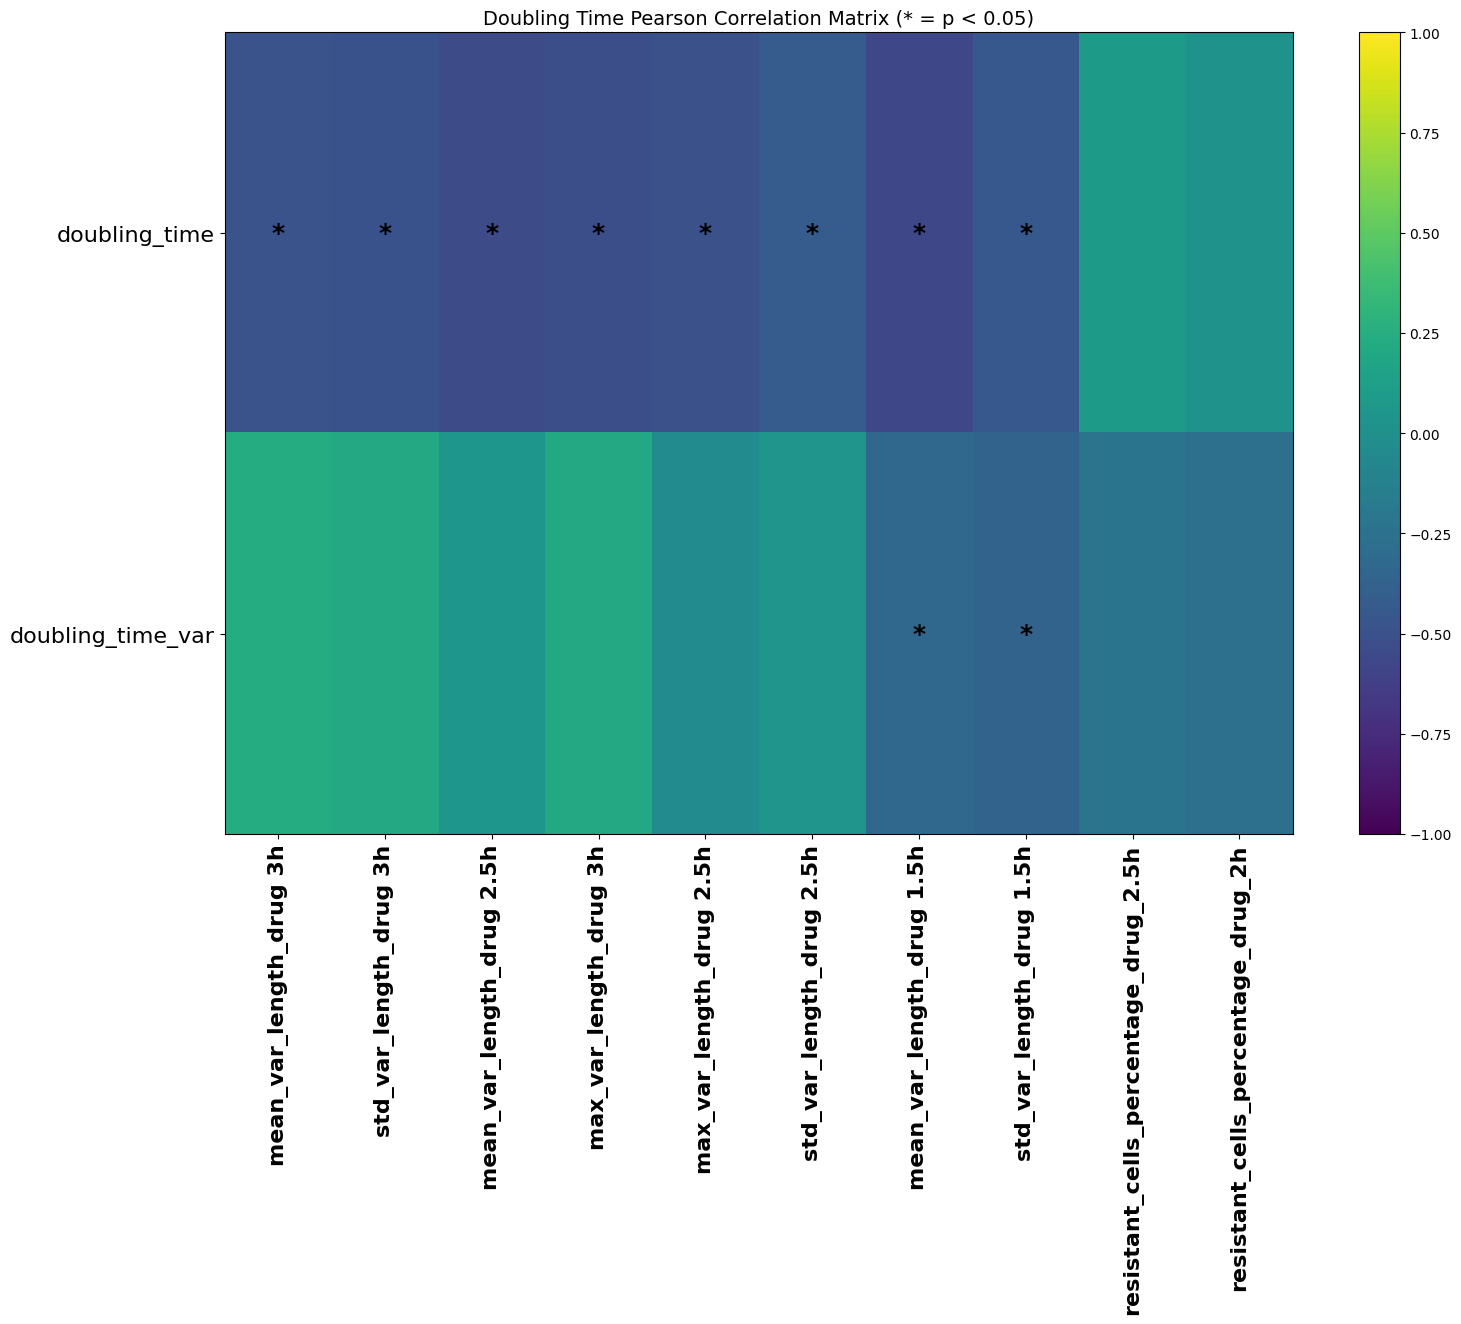

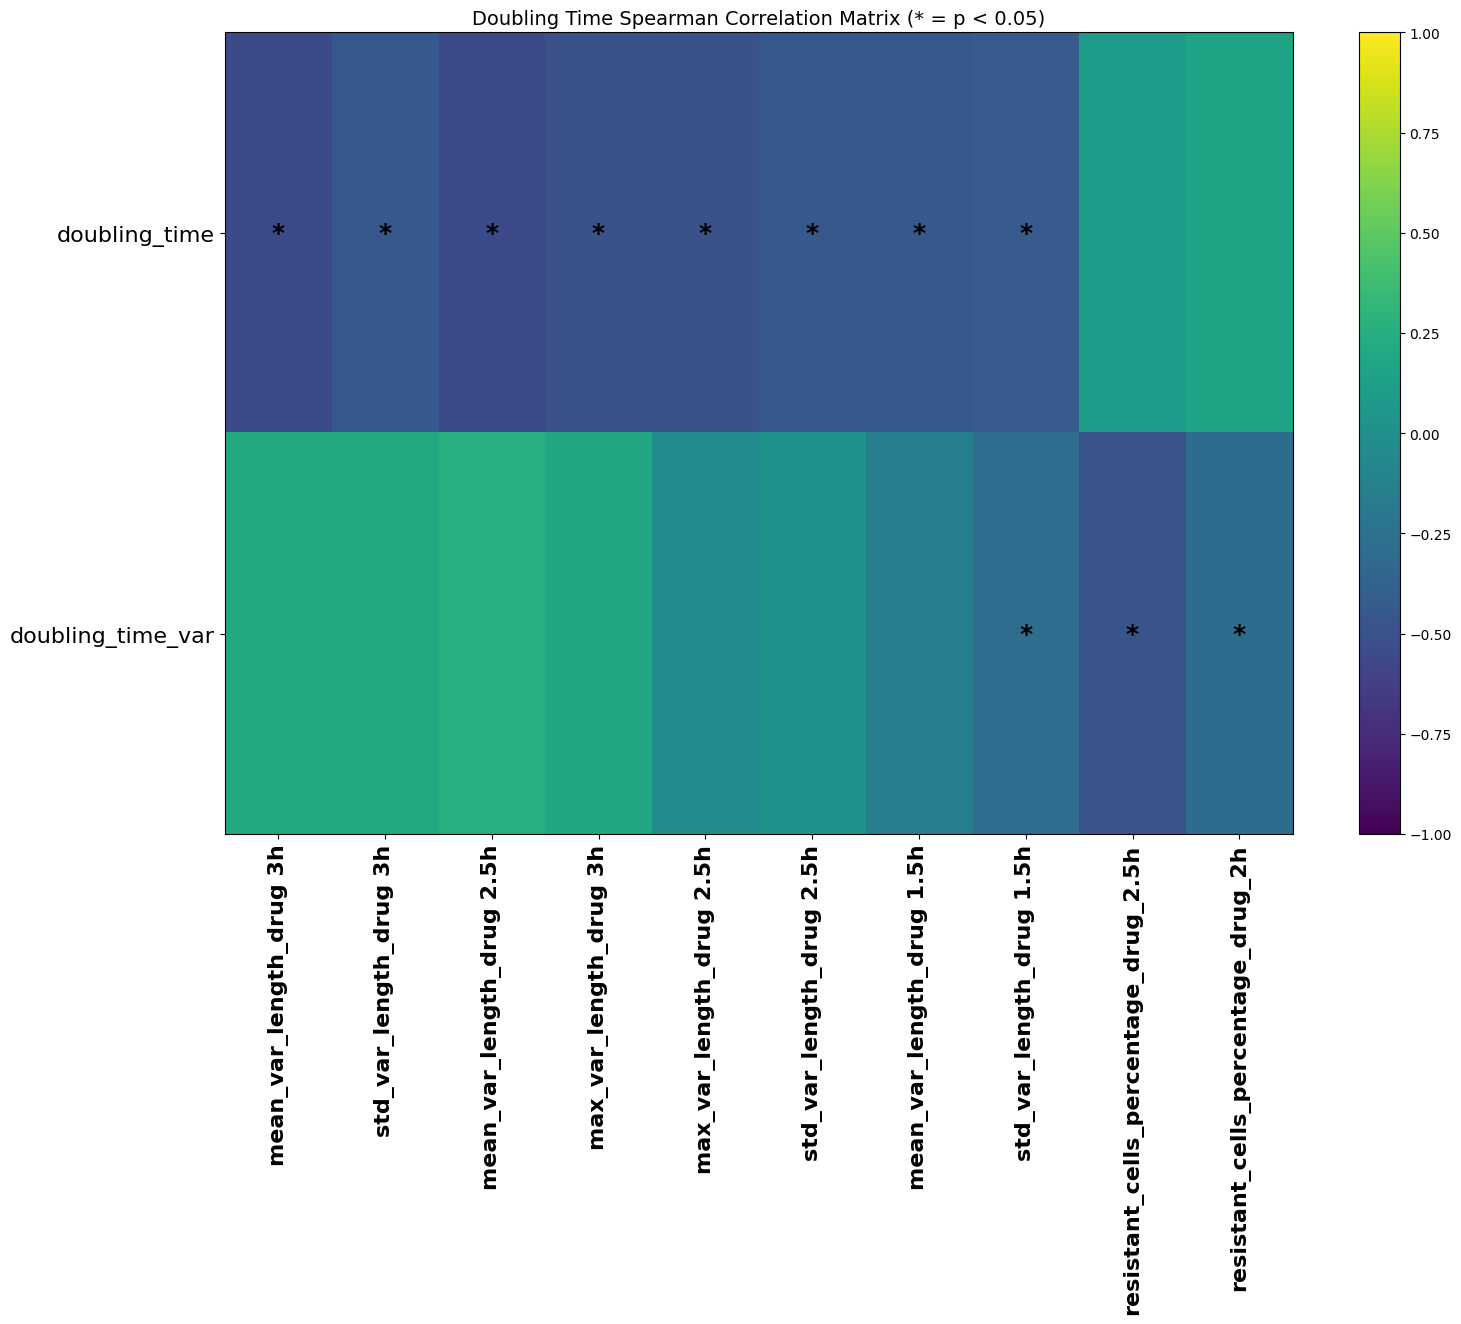

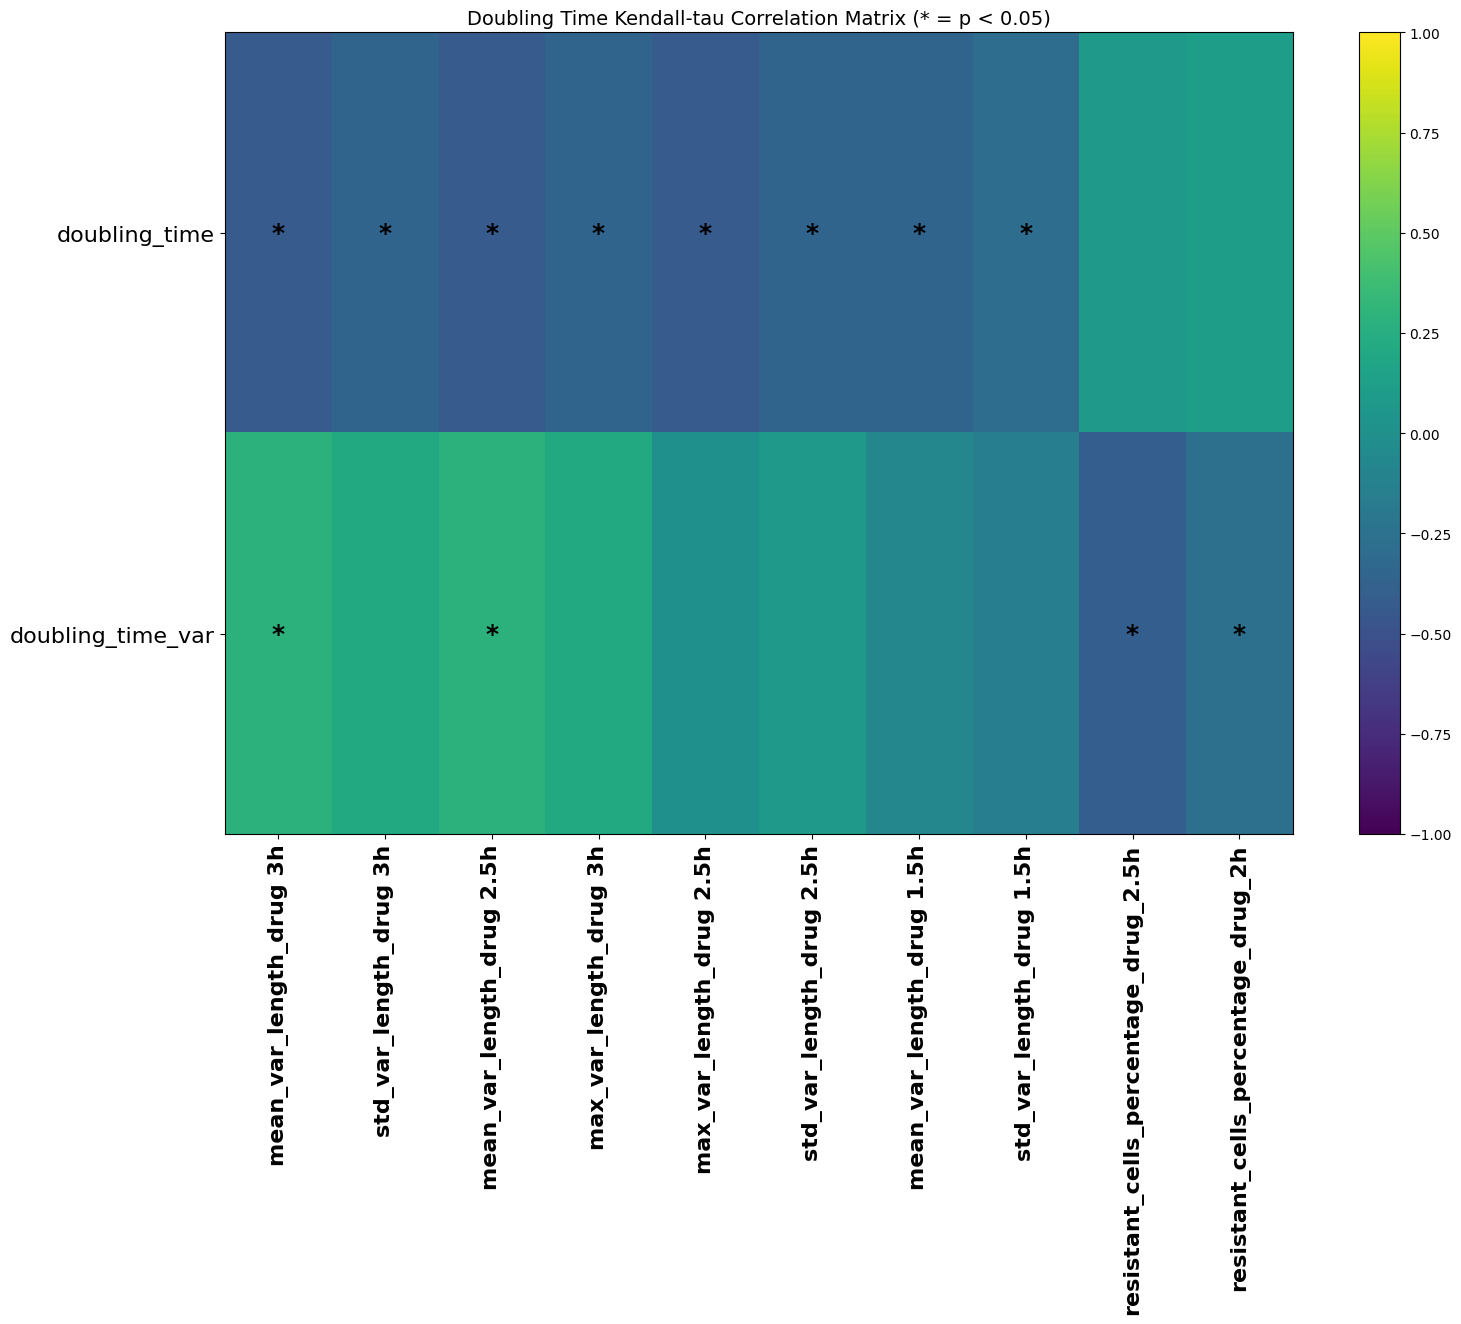

In [209]:
corr_pear, pvals_pear = compute_corr_and_p(doubling_time, microfluidics_features, method='pearson')
corr_spear, pvals_spear = compute_corr_and_p(doubling_time, microfluidics_features, method='spearman')
corr_kendall, pvals_kendall = compute_corr_and_p(doubling_time, microfluidics_features, method='kendall')


plot_corr_with_sig_imshow(
    corr=corr_pear,
    pvals=pvals_pear,
    title="Doubling Time Pearson Correlation Matrix (* = p < 0.05)",
    filename="doubling_time_pear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_spear,
    pvals=pvals_spear,
    title="Doubling Time Spearman Correlation Matrix (* = p < 0.05)",
    filename="doubling_time_spear_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)

plot_corr_with_sig_imshow(
    corr=corr_kendall,
    pvals=pvals_kendall,
    title="Doubling Time Kendall-tau Correlation Matrix (* = p < 0.05)",
    filename="doubling_time_kendall_corr_with_sig.png",
    output_folder=output_folder,
    alpha=0.5   # or 0.05 if you want standard significance
)
